# Pointing and 3D Spatial Understanding with Gemini 2.0 (Experimental)

This colab highlights some of the exciting use cases for Gemini 2.0 Flash in spatial understanding. It focuses on how [Gemini 2.0 Flash](https://ai.google.dev/gemini-api/docs/models/gemini-v2)'s image and real world understanding capabilities including pointing and 3D spatial understanding as briefly teased in the [Building with Gemini 2.0: Spatial understanding](https://www.youtube.com/watch?v=-XmoDzDMqj4) video.

:::{.callout-important}

Points and 3D bounding boxes are experimental. Use 2D bounding boxes for higher accuracy.

:::

Pointing is an important capability for vision language models, because that allows the model to refer to an entity precisely. Gemini 2.0 Flash has improved accuracy on spatial understanding, with 2D point prediction as an experimental feature. Below you'll see that pointing can be combined with reasoning.

![Pointing Example](https://storage.googleapis.com/generativeai-downloads/images/pointing.png)

Traditionally, a Vision Language Model (VLM) sees the world in 2D, however, [Gemini 2.0 Flash](https://ai.google.dev/gemini-api/docs/models/gemini-v2) can perform 3D detection. The model has a general sense of the space and knows where the objects are in 3D space.

![3D Detection Example](https://storage.googleapis.com/generativeai-downloads/images/box_3d.png)

The model will respond to spatial understanding-related requests in json format to facilitate parsing, and the coordinates always have the same conventions. For this example to be more readable, it overlays the spatial signals on the image, and the readers can hover their cursor on the image to get the complete response. The coordinates are in the image frame, and are normalized into an integer between 0-1000. The top left is `(0,0)` and the bottom right is `(1000,1000)`. The point is in `[y, x]` order, and 2d bounding boxes are in `y_min, x_min, y_max, x_max` order.

Additionally, 3D bounding boxes are represented with 9 numbers, the first 3 numbers represent the center of the object in camera frame, they are in metric units; the next 3 numbers represent the size of the object in meters, and the last 3 numbers are Euler angles representing row, pitch and yaw, they are in degree.

To learn more about 2D spatial understanding, please take a look at [2d examples](../quickstarts/Spatial_understanding.ipynb) and the [Spatial understanding example](https://aistudio.google.com/starter-apps/spatial) from [Google AI Studio](https://aistudio.google.com).

![Cupcakes with Bounding Box](https://storage.googleapis.com/generativeai-downloads/images/cupcakes_with_bbox.png)


## Setup

### Install the Google GenAI SDK

Install the Google GenAI SDK from [npm](https://www.npmjs.com/package/@google/genai). 

```bash
$ npm install @google/genai
```

### Setup your API key

You can [create](https://aistudio.google.com/app/apikey) your API key using Google AI Studio with a single click.

Remember to treat your API key like a password. Don't accidentally save it in a notebook or source file you later commit to GitHub. In this notebook we will be storing the API key in a `.env` file. You can also set it as an environment variable or use a secret manager. 

Here's how to set it up in a `.env` file:

```bash
$ touch .env
$ echo "GEMINI_API_KEY=<YOUR_API_KEY>" >> .env
```

:::{.callout-tip}

Another option is to set the API key as an environment variable. You can do this in your terminal with the following command:

```bash
$ export GEMINI_API_KEY="<YOUR_API_KEY>"
```
:::

### Load the API key

To load the API key from the `.env` file, we will use the `dotenv` package. This package loads environment variables from a `.env` file into `process.env`. 

```bash
$ npm install dotenv
```

Then, we can load the API key in our code:


In [1]:
const dotenv = require("dotenv") as typeof import("dotenv");

dotenv.config({
  path: "../.env",
});

const GEMINI_API_KEY = process.env.GEMINI_API_KEY ?? "";
if (!GEMINI_API_KEY) {
  throw new Error("GEMINI_API_KEY is not set in the environment variables");
}
console.log("GEMINI_API_KEY is set in the environment variables");


GEMINI_API_KEY is set in the environment variables


:::{.callout-note}
In our particular case the `.env` is is one directory up from the notebook, hence we need to use `../` to go up one directory. If the `.env` file is in the same directory as the notebook, you can omit it altogether. 

```
│
├── .env
└── examples
    └── Spatial_understanding_3d.ipynb
```
:::


### Initialize SDK Client

With the new SDK, now you only need to initialize a client with you API key (or OAuth if using [Vertex AI](https://cloud.google.com/vertex-ai)). The model is now set in each call.


In [2]:
const google = require("@google/genai") as typeof import("@google/genai");

const ai = new google.GoogleGenAI({ apiKey: GEMINI_API_KEY });


### Select a model

Now select the model you want to use in this guide, either by selecting one in the list or writing it down. Keep in mind that some models, like the 2.5 ones are thinking models and thus take slightly more time to respond (cf. [thinking notebook](../quickstarts/Get_started_thinking.ipynb) for more details and in particular learn how to switch the thiking off).


In [3]:
const tslab = require("tslab") as typeof import("tslab");

const MODEL_ID = "gemini-2.5-flash-preview-05-20";


### Load sample images


In [4]:
const fs = require("fs") as typeof import("fs");
const path = require("path") as typeof import("path");

const downloadFile = async (url: string, filePath: string) => {
  const response = await fetch(url);
  if (!response.ok) {
    throw new Error(`Failed to download file: ${response.statusText}`);
  }
  fs.mkdirSync(path.dirname(filePath), { recursive: true });
  const buffer = await response.blob();
  const bufferData = Buffer.from(await buffer.arrayBuffer());
  fs.writeFileSync(filePath, bufferData);
};


In [ ]:
const IMAGE_MAP: Record<string, string> = {
  kitchen: "https://storage.googleapis.com/generativeai-downloads/images/kitchen.jpg",
  room: "https://storage.googleapis.com/generativeai-downloads/images/room-clock.jpg",
  spill: "https://storage.googleapis.com/generativeai-downloads/images/spill.jpg",
  tool: "https://storage.googleapis.com/generativeai-downloads/images/tool.png",
  music_0: "https://storage.googleapis.com/generativeai-downloads/images/music_0.jpg",
  music_1: "https://storage.googleapis.com/generativeai-downloads/images/music_1.jpg",
  traj_00: "https://storage.googleapis.com/generativeai-downloads/images/traj_00.jpg",
  traj_01: "https://storage.googleapis.com/generativeai-downloads/images/traj_01.jpg",
  shoe_bench_0: "https://storage.googleapis.com/generativeai-downloads/images/shoe_bench_0.jpg",
  shoe_bench_1: "https://storage.googleapis.com/generativeai-downloads/images/shoe_bench_1.jpg",
};

for (const [key, url] of Object.entries(IMAGE_MAP)) {
  const filePath = path.join("../assets", "Spatial_understanding_3d", `${key}.jpg`);
  await downloadFile(url, filePath);
}


## Pointing to items using Gemini

Instead of asking for [bounding boxes](../quickstarts/Spatial_understanding.ipynb), you can ask Gemini to point to things on the image. Depending on your use-case it might be sufficent and will less clutter the images.

Just be careful that the format Gemini knows the best is (y, x), so it's better to stick to it.

To prevent the model from repeating itself, it is recommended to use a temperature over 0, in this case 0.5. Limiting the number of items (10 in this case) is also a way to prevent the model from looping and to speed up the decoding of the corrdinates. You can experiment with these parameters and find what works best for your use-case.


### Analyze the image using Gemini


In [ ]:
const tool_image_response = await ai.models.generateContent({
  model: MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "tool.jpg")).toString("base64"),
      "image/jpeg"
    ),
    `
      Point to no more than 10 items in the image, include spill.
      The answer should follow the json format: [{"point": , "label": }, ...]. The points are in [y, x] format normalized to 0-1000.
    `,
  ],
  config: {
    temperature: 0.5,
  },
});
tslab.display.markdown(tool_image_response.text ?? "");


```json
[
  {"point": [581, 344], "label": "C-clamp body"},
  {"point": [486, 703], "label": "Sliding T-handle"},
  {"point": [435, 436], "label": "Swivel pad"},
  {"point": [468, 621], "label": "Screw (spindle)"},
  {"point": [691, 343], "label": "3\"\" marking"},
  {"point": [507, 169], "label": "Fixed jaw (anvil)"},
  {"point": [804, 735], "label": "Wood grain"},
  {"point": [638, 770], "label": "Shadow under the clamp"},
  {"point": [445, 559], "label": "Light reflection on clamp"},
  {"point": [223, 501], "label": "Background wood surface"}
]
```

In [8]:
function parseCodeBlock(text: string): string | null {
  const matchFound = /```json\n([\s\S]*?)```/.exec(text);
  if (matchFound) {
    return matchFound[1];
  } else {
    console.error("No JSON code found in the response");
    return null;
  }
}


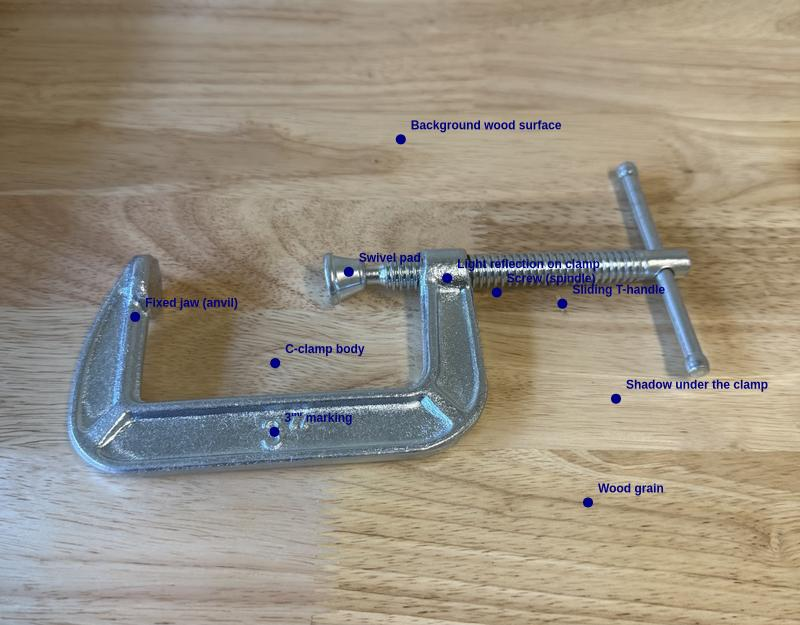

In [ ]:
const canvas = require("canvas") as typeof import("canvas");

interface Point {
  point: [number, number];
  label: string;
  in_frame?: boolean; // Optional, used for filtering points in some examples
}

async function drawPoints(imagePath: string, points: Point[], color = "navy", size = "12"): Promise<Buffer> {
  const img = await canvas.loadImage(imagePath);
  const { width } = img;
  const { height } = img;

  const canvasElement = canvas.createCanvas(width, height);
  const ctx = canvasElement.getContext("2d");

  ctx.drawImage(img, 0, 0);

  points.forEach((point) => {
    const x = (point.point[1] / 1000) * width;
    const y = (point.point[0] / 1000) * height;

    ctx.beginPath();
    ctx.arc(x, y, 5, 0, Math.PI * 2);
    ctx.fillStyle = color;
    ctx.fill();
    ctx.font = `bold ${size}px Arial`;
    ctx.fillText(point.label, x + 10, y - 10);
  });

  return canvasElement.toBuffer("image/jpeg");
}

const tool_image_code = parseCodeBlock(tool_image_response.text ?? "");
if (tool_image_code) {
  const tool_image_points: Point[] = JSON.parse(tool_image_code) as Point[];
  const tool_image_path = path.join("../assets", "Spatial_understanding_3d", "tool.jpg");
  const tool_image_with_points = await drawPoints(tool_image_path, tool_image_points);

  tslab.display.jpeg(new Uint8Array(tool_image_with_points));
}


### Pointing and reasoning

Pointing and reasoning
You can use Gemini's reasoning capabilities on top of its pointing ones as in the [2d bounding box](../quickstarts/Spatial_understanding.ipynb#scrollTo=GZbhjYkUA86w) example and ask for more detailled labels.

In this case you can do it by adding this sentence to the prompt: "Explain how to use each part, put them in the label field, remove duplicated parts and instructions".


In [ ]:
const pointing_and_reasoning_response = await ai.models.generateContent({
  model: MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "tool.jpg")).toString("base64"),
      "image/jpeg"
    ),
    `
      Pinpoint no more than 10 items in the image.
      The answer should follow the json format: [{"point": , "label": }, ...]. The points are in [y, x] format normalized to 0-1000. One element a line.
      Explain how to use each part, put them in the label field, remove duplicated parts and instructions.
    `,
  ],
  config: {
    temperature: 0.5,
  },
});
tslab.display.markdown(pointing_and_reasoning_response.text ?? "");


```json
[
  {"point": [570, 345], "label": "C-frame: The main body of the clamp that provides the overall structure and holds the components together."},
  {"point": [488, 555], "label": "Screw (Spindle): The long, threaded rod that moves the swivel pad to apply pressure."},
  {"point": [465, 835], "label": "Handle (T-bar): The crossbar used to turn the screw, providing leverage for tightening or loosening."},
  {"point": [435, 430], "label": "Swivel Pad: The flat, circular piece at the end of the screw that pivots to conform to the workpiece, distributing pressure and preventing damage."},
  {"point": [492, 165], "label": "Fixed Jaw (Anvil): The stationary end of the C-frame, opposite the swivel pad, providing the fixed point against which the workpiece is clamped."},
  {"point": [695, 335], "label": "Size Marking \"3\"\": Indicates the nominal size or maximum opening of the clamp."}
]
```

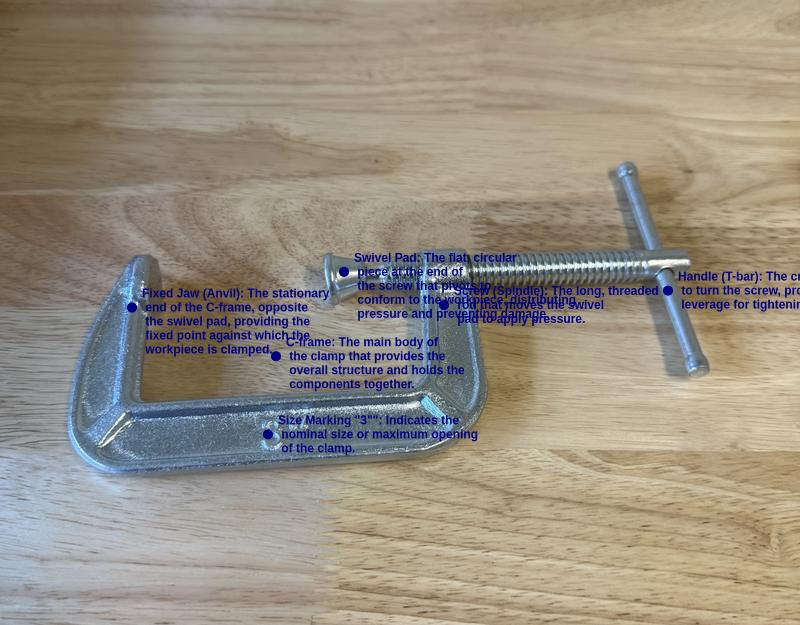

In [ ]:
const tool_image_reasoning_code = parseCodeBlock(pointing_and_reasoning_response.text ?? "");

if (tool_image_reasoning_code) {
  const tool_image_reasoning_points: Point[] = JSON.parse(tool_image_reasoning_code) as Point[];
  tool_image_reasoning_points.forEach((point) => {
    point.label = point.label.replace(/([a-zA-Z0-9()-:"]+(?:\s+[a-zA-Z0-9()-:"]+){0,4})/g, "$1\n").trim();
  });
  const tool_image_reasoning_path = path.join("../assets", "Spatial_understanding_3d", "tool.jpg");
  const tool_image_reasoning_with_points = await drawPoints(tool_image_reasoning_path, tool_image_reasoning_points);

  tslab.display.jpeg(new Uint8Array(tool_image_reasoning_with_points));
}


### More pointing and reasoning examples

Expend this section to see more examples of images and prompts you can use. Experiment with them and find what works bets for your use-case.

#### Kitchen safety


In [ ]:
const kitchen_image_response = await ai.models.generateContent({
  model: MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "kitchen.jpg")).toString("base64"),
      "image/jpeg"
    ),
    `
      Point to no more than 10 items in the image.
      The answer should follow the json format: [{"point": , "label": }, ...]. The points are in [y, x] format normalized to 0-1000. One element a line.
      Explain how to prevent kids from getting hurt, put them in the label field, remove duplicated parts and instructions.
    `,
  ],
  config: {
    temperature: 0.5,
  },
});
tslab.display.markdown(kitchen_image_response.text ?? "");


```json
[
  {"point": [672, 464], "label": "Keep oven door closed and use oven locks."},
  {"point": [643, 856], "label": "Use stove knob covers and never leave hot pans unattended."},
  {"point": [528, 715], "label": "Keep small appliances like toaster ovens out of reach or unplugged when not in use."},
  {"point": [516, 626], "label": "Keep coffee makers and hot beverages away from the edge of counters."},
  {"point": [542, 331], "label": "Store toasters and other small appliances away when not in use."},
  {"point": [499, 290], "label": "Store knives and sharp utensils in a locked drawer or knife block out of reach."},
  {"point": [628, 102], "label": "Ensure sinks are not filled with hot water when children are present."},
  {"point": [665, 276], "label": "Keep dishwasher closed and use child locks."},
  {"point": [507, 131], "label": "Place cleaning supplies and chemicals in high, locked cabinets."},
  {"point": [220, 222], "label": "Secure curtains and blinds with safety clips to prevent strangulation hazards."}
]
```

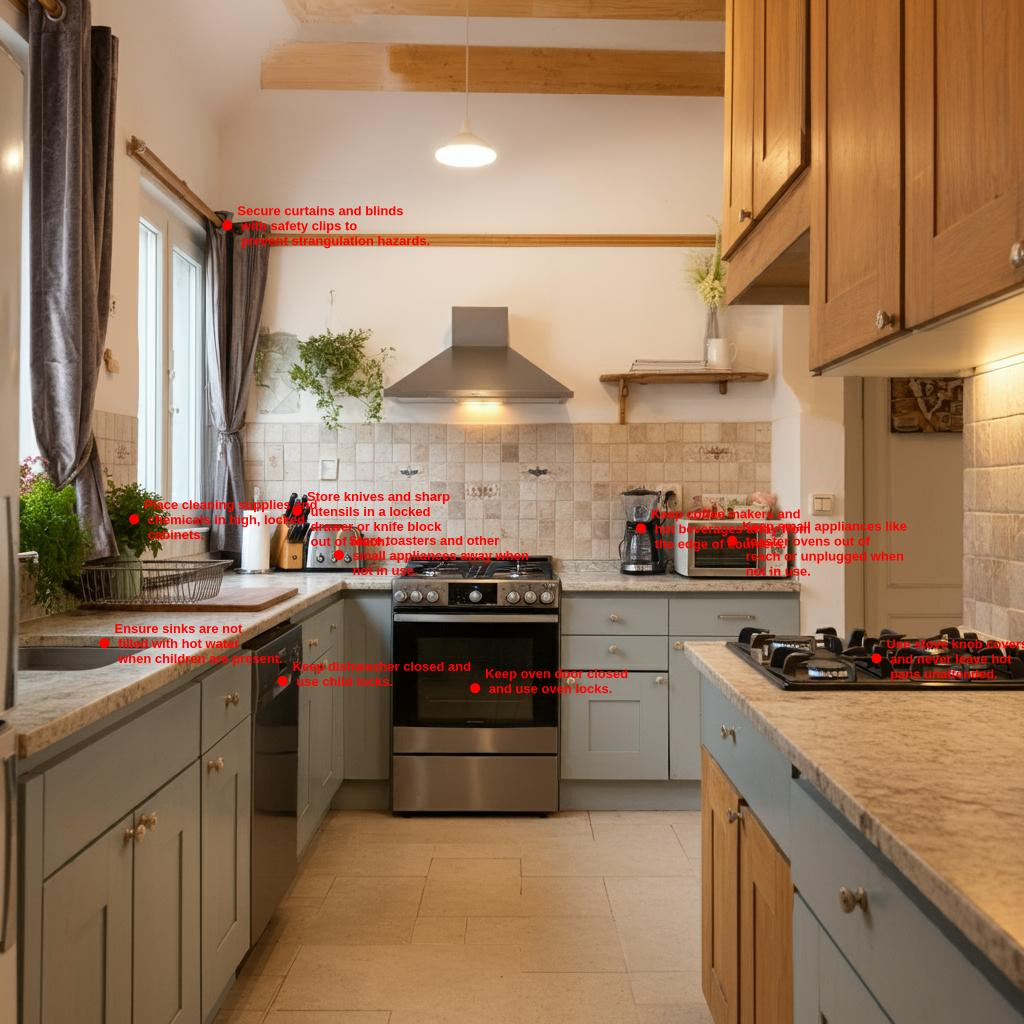

In [ ]:
const kitchen_image_code = parseCodeBlock(kitchen_image_response.text ?? "");
if (kitchen_image_code) {
  const kitchen_image_points: Point[] = JSON.parse(kitchen_image_code) as Point[];
  kitchen_image_points.forEach((point) => {
    point.label = point.label.replace(/([a-zA-Z0-9()-:"]+(?:\s+[a-zA-Z0-9()-:"]+){0,4})/g, "$1\n").trim();
  });
  const kitchen_image_path = path.join("../assets", "Spatial_understanding_3d", "kitchen.jpg");
  const kitchen_image_with_points = await drawPoints(kitchen_image_path, kitchen_image_points, "red", "13");

  tslab.display.jpeg(new Uint8Array(kitchen_image_with_points));
}


#### Office improvements


In [ ]:
const office_image_response = await ai.models.generateContent({
  model: MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "room.jpg")).toString("base64"),
      "image/jpeg"
    ),
    `
      Point to no more than 10 items in the image.
      The answer should follow the json format: [{"point": , "label": }, ...]. The points are in [y, x] format normalized to 0-1000. One element a line.
      Give advices on how to make this space more feng-shui, put them in the label field, remove duplicated parts and instructions.
    `,
  ],
  config: {
    temperature: 0.5,
  },
});
tslab.display.markdown(office_image_response.text ?? "");


```json
[
  {
    "point": [703, 500],
    "label": "Maintain a clear and organized desk surface to promote mental clarity and efficient workflow. A sturdy, well-maintained desk symbolizes stability and support in your endeavors."
  },
  {
    "point": [781, 500],
    "label": "A chair with a high back provides excellent support, symbolizing a 'mountain' behind you for stability and protection in your career. Ensure it's comfortable and allows for good posture."
  },
  {
    "point": [456, 250],
    "label": "Maximize natural light for positive energy flow (Yang energy). If the view is busy or distracting, use curtains (like the existing ones) to soften the energy and provide a sense of security without blocking all light."
  },
  {
    "point": [390, 250],
    "label": "Healthy plants bring vibrant living energy (Wood element), purify the air, and soften sharp angles. Ensure they are thriving and well-maintained to symbolize growth and vitality."
  },
  {
    "point": [520, 100],
    "label": "While organized, clear bins can expose visual clutter. Consider using opaque storage or decorative boxes for items that don't need to be seen, promoting a calmer and more harmonious visual environment."
  },
  {
    "point": [553, 500],
    "label": "Keep your screen clean and free of distractions. Ensure it's ergonomically positioned to support good posture and clear focus during work, allowing energy to flow smoothly."
  },
  {
    "point": [260, 500],
    "label": "This large, empty space is an opportunity to add inspiring artwork, a vision board, or a corkboard for ideas. This activates the space, providing a positive focal point and stimulating creativity and ambition."
  },
  {
    "point": [703, 300],
    "label": "When not in active use, keep laptops or other devices neatly stored or closed. This reduces visual clutter and helps to create a clear boundary between work and rest, promoting mental clarity."
  },
  {
    "point": [716, 700],
    "label": "Keep desk accessories and personal items neatly arranged and only what's essential on the desk surface. A tidy desk promotes clear thinking and reduces mental clutter, allowing for better focus."
  },
  {
    "point": [716, 880],
    "label": "Utilize organizers to keep papers and documents tidy and easily accessible. Regularly clear out old or unnecessary items to prevent stagnant energy and promote efficiency."
  }
]
```

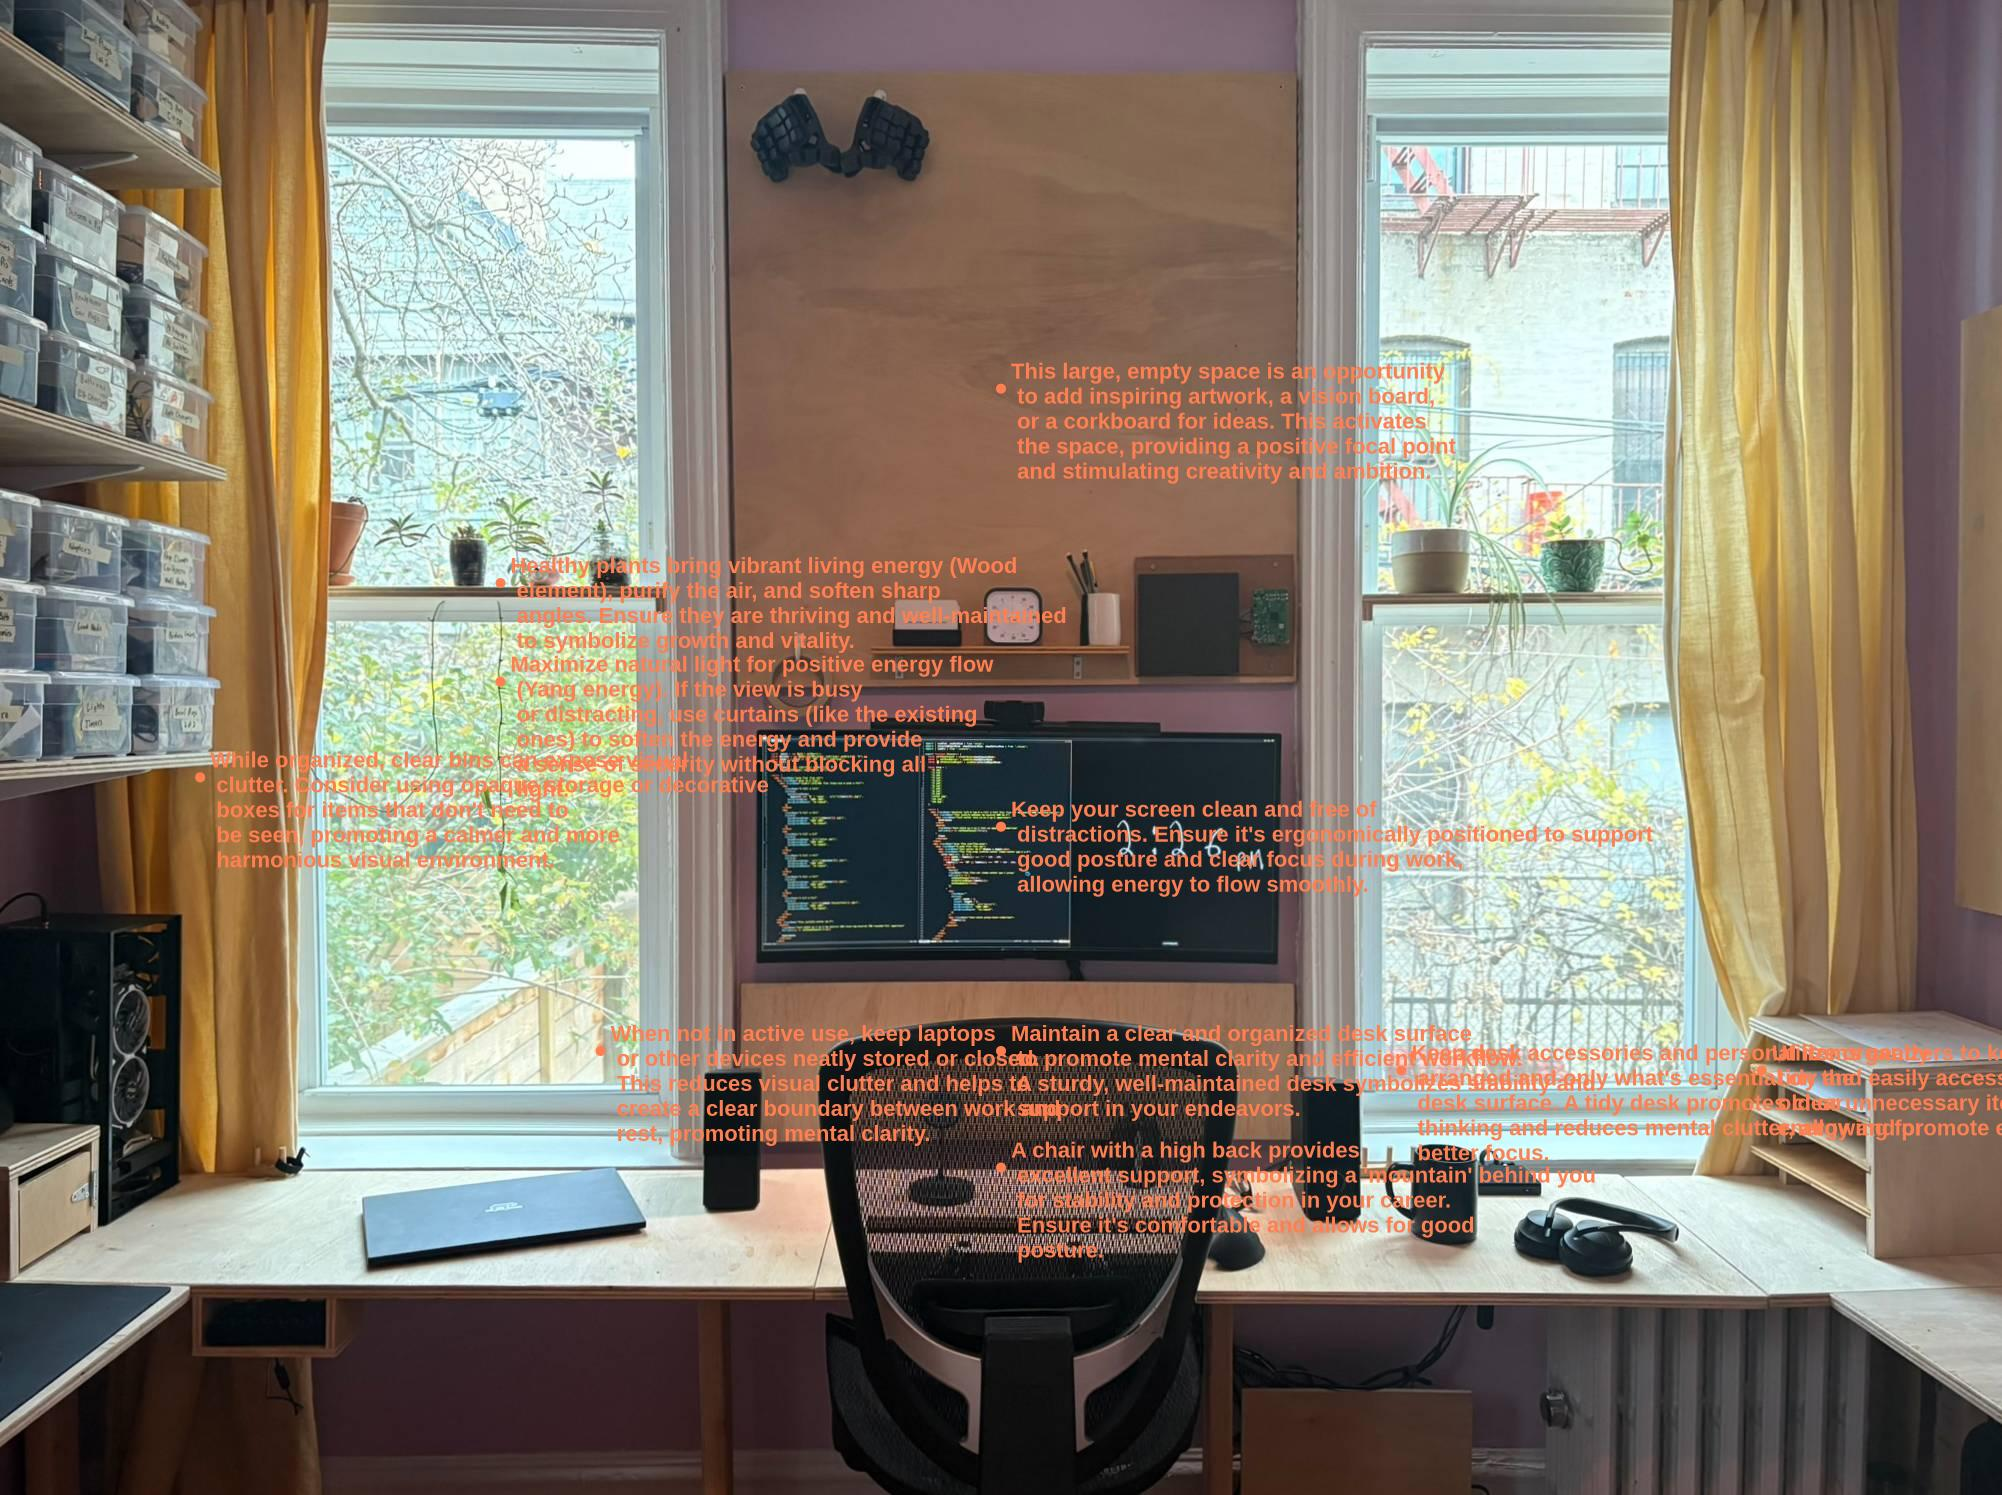

In [ ]:
const office_image_code = parseCodeBlock(office_image_response.text ?? "");
if (office_image_code) {
  const office_image_points: Point[] = JSON.parse(office_image_code) as Point[];
  office_image_points.forEach((point) => {
    point.label = point.label.replace(/([a-zA-Z0-9()-:"]+(?:\s+[a-zA-Z0-9()-:"]+){0,4})/g, "$1\n").trim();
  });
  const office_image_path = path.join("../assets", "Spatial_understanding_3d", "room.jpg");
  const office_image_with_points = await drawPoints(office_image_path, office_image_points, "coral", "22");

  tslab.display.jpeg(new Uint8Array(office_image_with_points));
}


#### Trajectories - Example 1

Here are two examples of asking Gemini to predict list of points that represent trajectories. This first example shows how to interpolate trajectories between a start and end point.

The image used here is from [Ego4D](https://ego4d-data.org/) with license [here](https://ego4d-data.org/pdfs/Ego4D-Licenses-Draft.pdf).


In [ ]:
const trajectory_image_response_1 = await ai.models.generateContent({
  model: MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "traj_00.jpg")).toString("base64"),
      "image/jpeg"
    ),
    `
      Point to the left hand and the handle of the blue screwdriver, and a trajectory of 6 points connecting them with no more than 10 items.
      The points should be labeled by order of the trajectory, from '0' (start point) to '5' (final point)
      The answer should follow the json format: [{"point": , "label": }, ...].
      The points are in [y, x] format normalized to 0-1000.
    `,
  ],
  config: {
    temperature: 0.5,
  },
});
tslab.display.markdown(trajectory_image_response_1.text ?? "");


```json
[
  {"point": [834, 451], "label": "0"},
  {"point": [756, 471], "label": "1"},
  {"point": [676, 492], "label": "2"},
  {"point": [587, 513], "label": "3"},
  {"point": [504, 532], "label": "4"},
  {"point": [436, 355], "label": "5"}
]
```

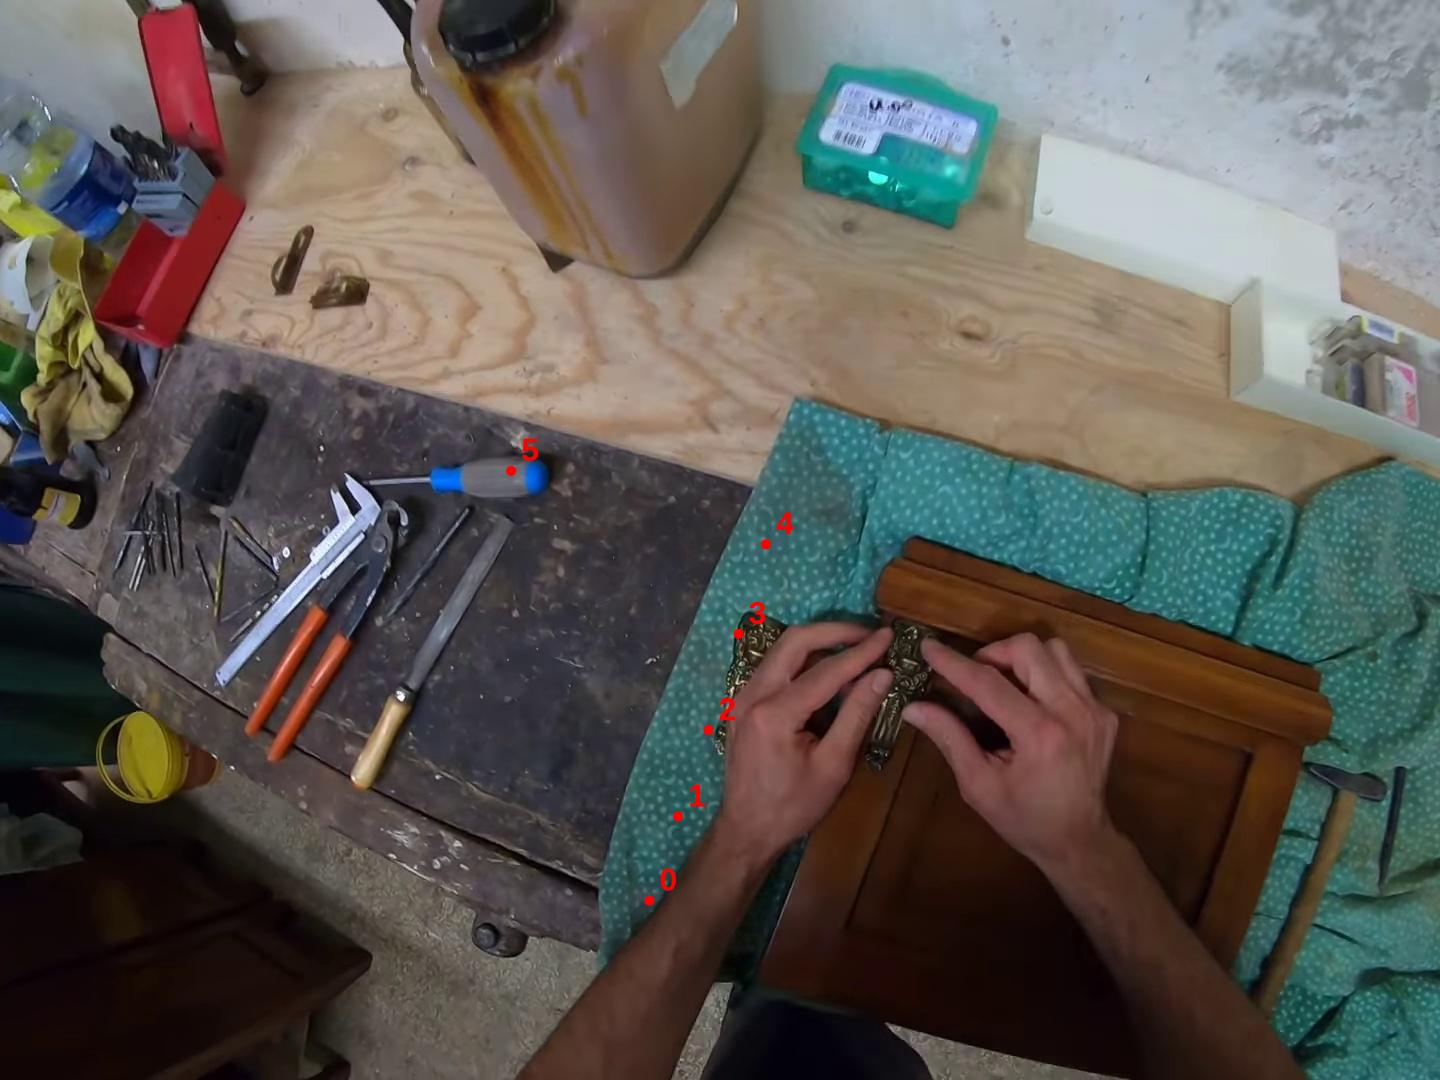

In [ ]:
const trajectory_1_image_code_1 = parseCodeBlock(trajectory_image_response_1.text ?? "");
if (trajectory_1_image_code_1) {
  const trajectory_1_image_points_1: Point[] = JSON.parse(trajectory_1_image_code_1) as Point[];
  const trajectory_1_image_path_1 = path.join("../assets", "Spatial_understanding_3d", "traj_00.jpg");
  const trajectory_1_image_with_points_1 = await drawPoints(
    trajectory_1_image_path_1,
    trajectory_1_image_points_1,
    "red",
    "32"
  );

  tslab.display.jpeg(new Uint8Array(trajectory_1_image_with_points_1));
}


#### Trajectories - Example 2

This second example shows how Gemini can predict a list of points that covers an area.

The image used here is from [BridgeData v2](https://rail-berkeley.github.io/bridgedata/) with the license [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).


In [ ]:
const trajectory_image_response_2 = await ai.models.generateContent({
  model: MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "traj_01.jpg")).toString("base64"),
      "image/jpeg"
    ),
    `
      Point to the the blue brush and a list of points covering the region of particles with no more than 10 items.
      The answer should follow the json format: [{"point": , "label": }, ...].
      The points are in [y, x] format normalized to 0-1000.
    `,
  ],
  config: {
    temperature: 0.5,
  },
});
tslab.display.markdown(trajectory_image_response_2.text ?? "");


```json
[
  {"point": [801, 650], "label": "the blue brush"},
  {"point": [527, 269], "label": "region of particles"},
  {"point": [507, 362], "label": "region of particles"},
  {"point": [484, 461], "label": "region of particles"},
  {"point": [569, 445], "label": "region of particles"},
  {"point": [604, 342], "label": "region of particles"},
  {"point": [638, 256], "label": "region of particles"},
  {"point": [712, 194], "label": "region of particles"},
  {"point": [732, 290], "label": "region of particles"},
  {"point": [689, 482], "label": "region of particles"},
  {"point": [569, 532], "label": "region of particles"}
]
```

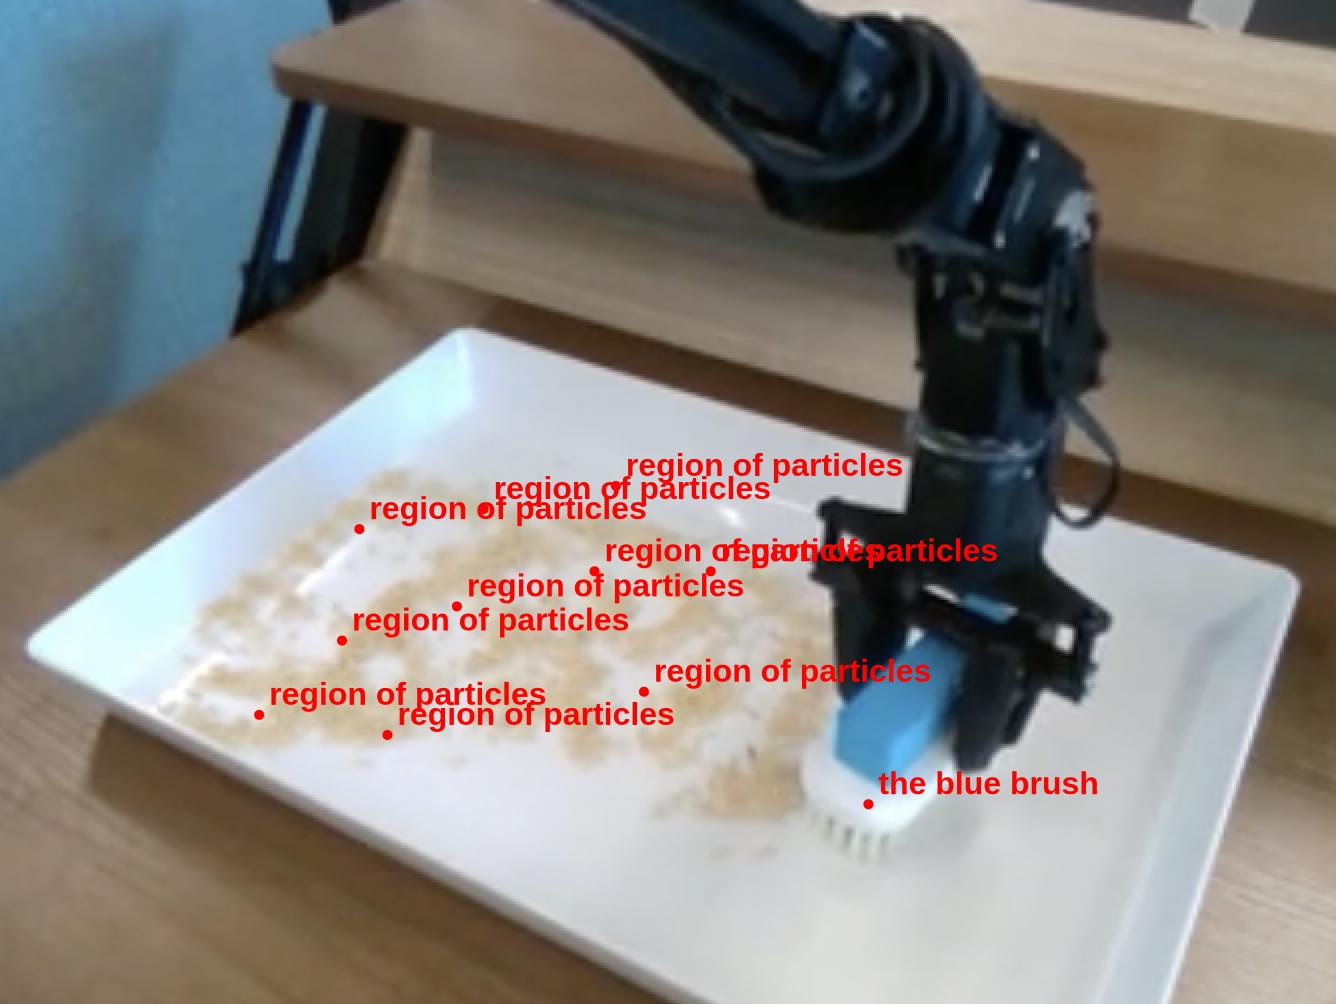

In [ ]:
const trajectory_2_image_code_2 = parseCodeBlock(trajectory_image_response_2.text ?? "");
if (trajectory_2_image_code_2) {
  const trajectory_2_image_points_2: Point[] = JSON.parse(trajectory_2_image_code_2) as Point[];
  const trajectory_2_image_path_2 = path.join("../assets", "Spatial_understanding_3d", "traj_01.jpg");
  const trajectory_2_image_with_points_2 = await drawPoints(
    trajectory_2_image_path_2,
    trajectory_2_image_points_2,
    "red",
    "32"
  );

  tslab.display.jpeg(new Uint8Array(trajectory_2_image_with_points_2));
}


## Analyzing 3D scenes with Gemini 2.0 (Experimental)

### Multiview Correspondence

Gemini can reason about different views of the same 3D scene.

In these examples, you first ask Gemini to label some points of interest in a view from a 3d scene. Next, you provide these coordinates and scene view, along with a new view of the same scene, and ask Gemini to point at the same points in the new view.

In these examples, you label the points as letters ('a','b','c' etc.) rather than semantic labels (e.g. 'guitar', 'drum'). This is to force the model to use the coordinates and the image, vs relying on the labels only.

Note that multiview correspondence is an experimental feature, which will further improve in future versions. This capability works best with the model ID `gemini-2.5-pro`

Musical Instruments step #1: Pointing


In [ ]:
const PRO_MODEL_ID = "gemini-2.5-pro";

const music_image_response_0 = await ai.models.generateContent({
  model: PRO_MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "music_0.jpg")).toString("base64"),
      "image/jpeg"
    ),
    `
      Point to the following points in the image:.
      a. Dumbak top
      b. Dumbak neck
      c. Cajon
      d. Guitar
      The answer should follow the json format: [{"point": , "label": }, ...]. The points are in [y, x] format normalized to 0-1000.
      The point labels should be 'a', 'b', 'c' etc. based on the provided list.
    `,
  ],
  config: {
    temperature: 0.5,
  },
});
tslab.display.markdown(music_image_response_0.text ?? "");


```json
[
  {"point": [673, 347], "label": "a"},
  {"point": [780, 356], "label": "b"},
  {"point": [550, 391], "label": "c"},
  {"point": [575, 773], "label": "d"}
]
```

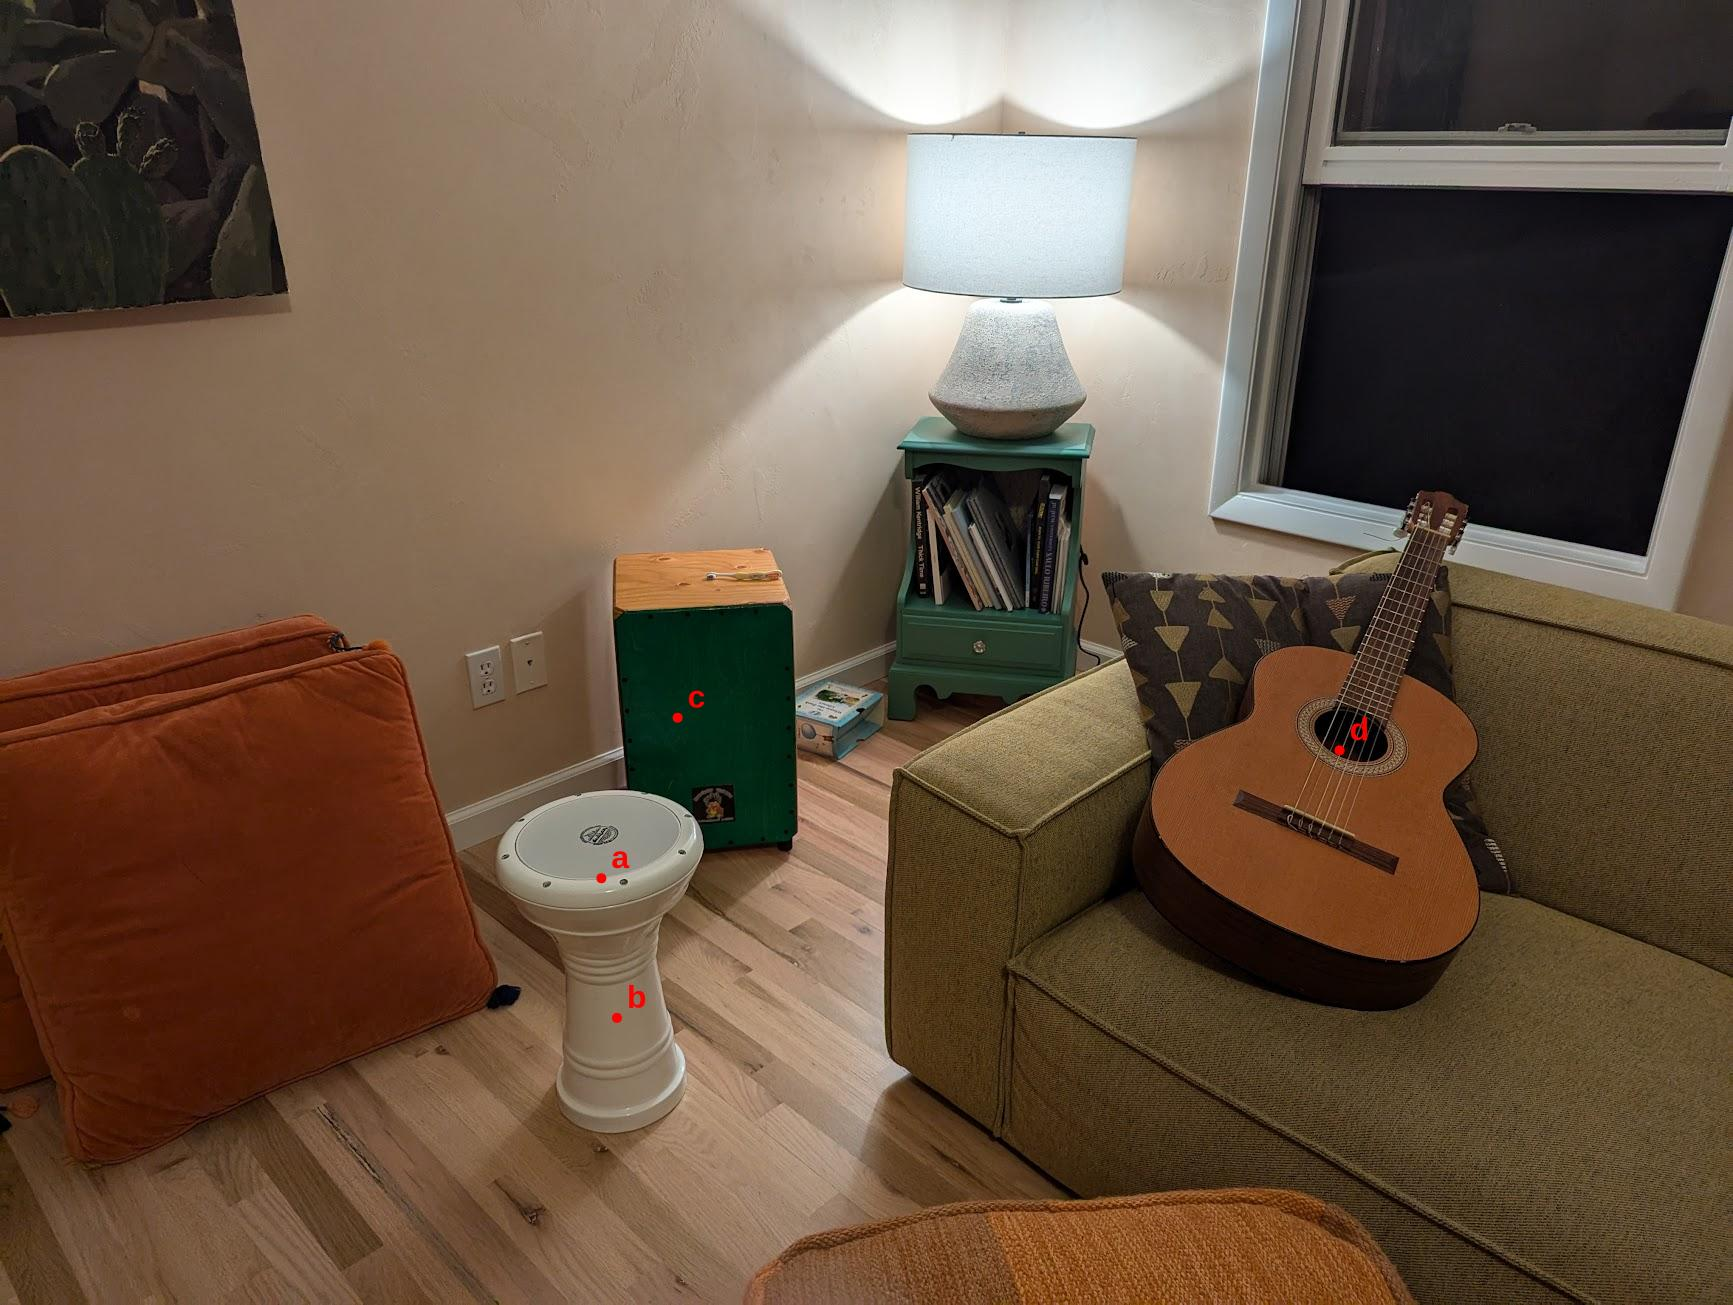

In [ ]:
const music_0_image_code_0 = parseCodeBlock(music_image_response_0.text ?? "");
if (music_0_image_code_0) {
  const music_0_image_points_0: Point[] = JSON.parse(music_0_image_code_0) as Point[];
  const music_0_image_path_0 = path.join("../assets", "Spatial_understanding_3d", "music_0.jpg");
  const music_0_image_with_points_0 = await drawPoints(music_0_image_path_0, music_0_image_points_0, "red", "32");

  tslab.display.jpeg(new Uint8Array(music_0_image_with_points_0));
}


Musical Instruments step #2: Multiview

Now take a picture from another angle and check if the model can find the corresponding points in the novel view.


In [ ]:
const music_1_image_response_1 = await ai.models.generateContent({
  model: PRO_MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "music_0.jpg")).toString("base64"),
      "image/jpeg"
    ),
    `
      For the following images, predict if the points referenced in the first image are in frame.
      If they are, also predict their 2D coordinates.
      Each entry in the response should be a single line and have the following keys:
      If the point is out of frame: 'in_frame': false, 'label' : .
      If the point is in frame: 'in_frame', 'point', 'label'.
    `,
    music_image_response_0.text ?? "",
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "music_1.jpg")).toString("base64"),
      "image/jpeg"
    ),
  ],
  config: {
    temperature: 0.1,
  },
});
tslab.display.markdown(music_1_image_response_1.text ?? "");


```json
[
  {"in_frame": true, "point": [408, 874], "label": "a"},
  {"in_frame": true, "point": [545, 800], "label": "b"},
  {"in_frame": false, "label": "c"},
  {"in_frame": true, "point": [575, 248], "label": "d"}
]
```

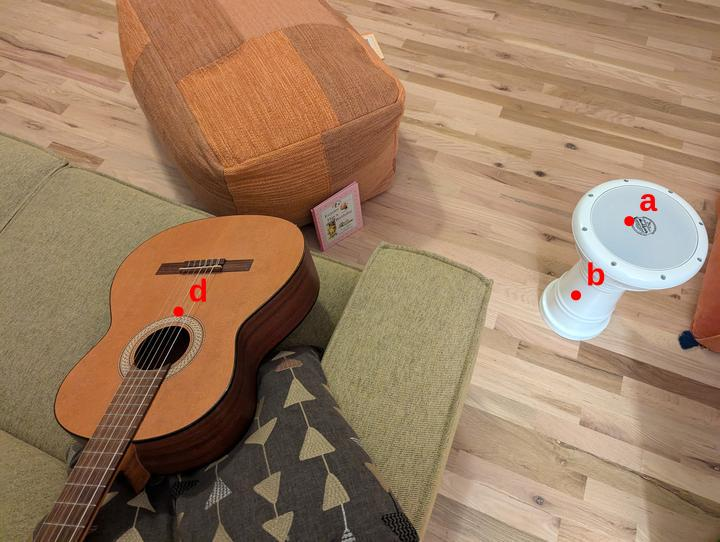

In [ ]:
const music_1_image_code_1 = parseCodeBlock(music_1_image_response_1.text ?? "");
if (music_1_image_code_1) {
  const music_1_image_points_1: Point[] = (JSON.parse(music_1_image_code_1) as Point[]).filter(
    (point) => point.in_frame
  );
  const music_1_image_path_1 = path.join("../assets", "Spatial_understanding_3d", "music_1.jpg");
  const music_1_image_with_points_1 = await drawPoints(music_1_image_path_1, music_1_image_points_1, "red", "32");

  tslab.display.jpeg(new Uint8Array(music_1_image_with_points_1));
}


Shoe Bench step #1: Pointing

Here's another example where instead of corresponding points across a large scene like a room, the model is doing so for a much smaller but clutter table-top scene.


In [ ]:
const shoe_bench_image_response_0 = await ai.models.generateContent({
  model: PRO_MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "shoe_bench_0.jpg")).toString("base64"),
      "image/jpeg"
    ),
    `
      Point to the each of the shoes in the image, and the toy jellyfish and backpack:

      The answer should follow the json format: [{"point": , "label": }, ...]. The points are in [y, x] format normalized to 0-1000.
      The point labels should be 'a', 'b', 'c' etc.
    `,
  ],
  config: {
    temperature: 0.1,
  },
});
tslab.display.markdown(shoe_bench_image_response_0.text ?? "");


```json
[
  {"point": [555, 318], "label": "a"},
  {"point": [730, 396], "label": "b"},
  {"point": [501, 520], "label": "c"},
  {"point": [573, 447], "label": "d"},
  {"point": [308, 678], "label": "e"}
]
```

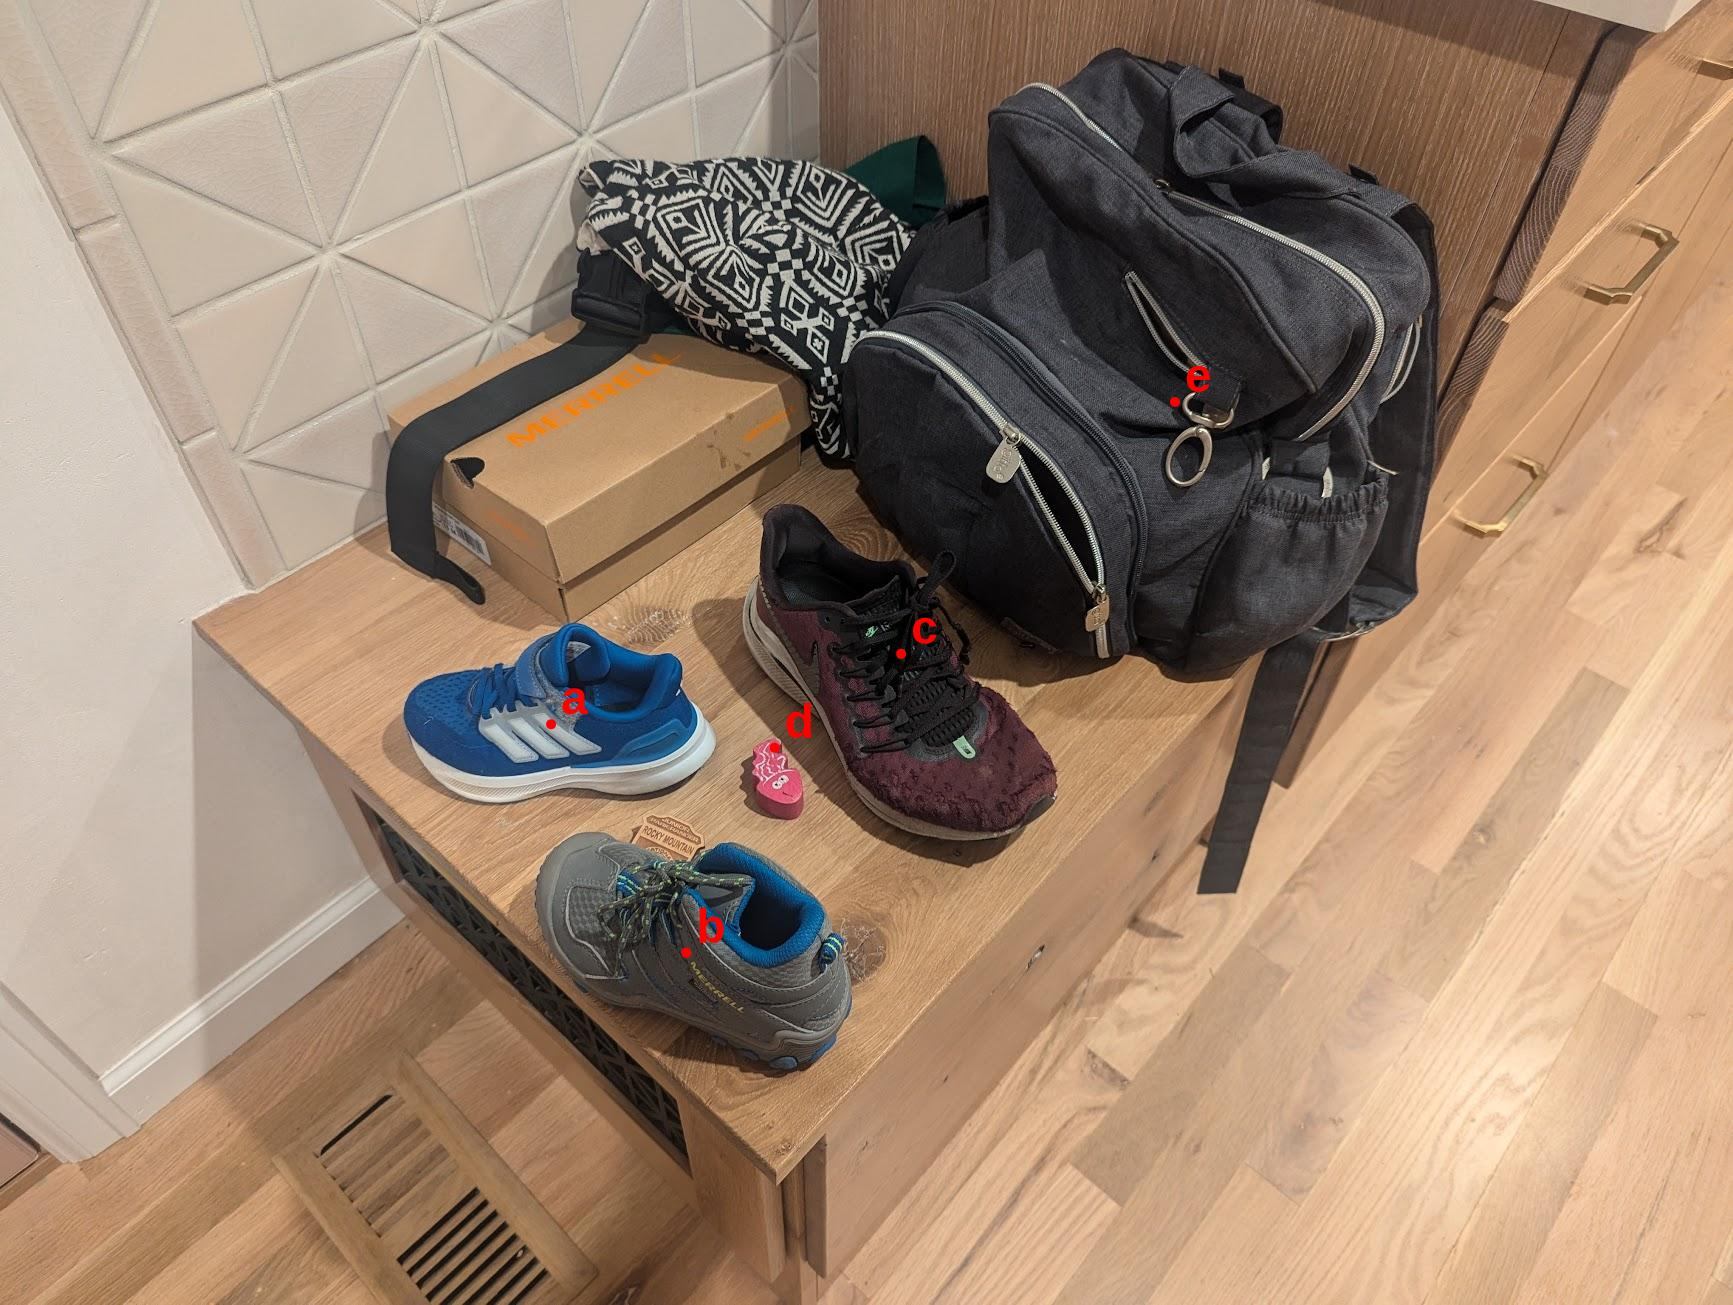

In [ ]:
const shoe_bench_image_code_0 = parseCodeBlock(shoe_bench_image_response_0.text ?? "");
if (shoe_bench_image_code_0) {
  const shoe_bench_image_points_0: Point[] = JSON.parse(shoe_bench_image_code_0) as Point[];
  const shoe_bench_image_path_0 = path.join("../assets", "Spatial_understanding_3d", "shoe_bench_0.jpg");
  const shoe_bench_image_with_points_0 = await drawPoints(
    shoe_bench_image_path_0,
    shoe_bench_image_points_0,
    "red",
    "48"
  );

  tslab.display.jpeg(new Uint8Array(shoe_bench_image_with_points_0));
}


Shoe Bench step #2: Multiview

Now take a picture from another angle and check if the model can find the corresponding points in the novel view.


In [ ]:
const shoe_bench_image_response_1 = await ai.models.generateContent({
  model: PRO_MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "shoe_bench_0.jpg")).toString("base64"),
      "image/jpeg"
    ),
    `
      For the following images, predict if the points referenced in the first image are in frame.
      If they are, also predict their 2D coordinates.
      Each entry in the response should be a single line and have the following keys:
      If the point is out of frame: 'in_frame': false, 'label' : .
      If the point is in frame: 'in_frame', 'point', 'label'.
    `,
    shoe_bench_image_response_0.text ?? "",
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "shoe_bench_1.jpg")).toString("base64"),
      "image/jpeg"
    ),
  ],
  config: {
    temperature: 0.1,
  },
});
tslab.display.markdown(shoe_bench_image_response_1.text ?? "");


```json
[
  {"in_frame": true, "point": [745, 429], "label": "a"},
  {"in_frame": true, "point": [806, 571], "label": "b"},
  {"in_frame": true, "point": [576, 544], "label": "c"},
  {"in_frame": true, "point": [669, 526], "label": "d"},
  {"in_frame": true, "point": [266, 542], "label": "e"}
]
```

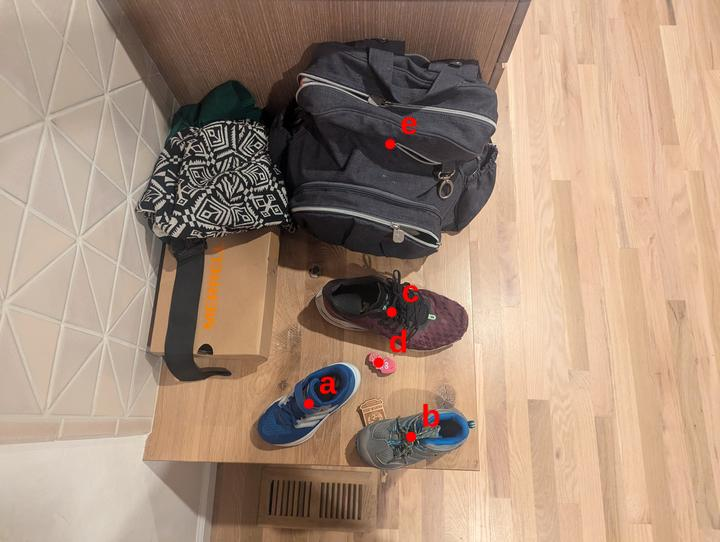

In [ ]:
const shoe_bench_image_code_1 = parseCodeBlock(shoe_bench_image_response_1.text ?? "");
if (shoe_bench_image_code_1) {
  const shoe_bench_image_points_1: Point[] = (JSON.parse(shoe_bench_image_code_1) as Point[]).filter(
    (point) => point.in_frame
  );
  const shoe_bench_image_path_1 = path.join("../assets", "Spatial_understanding_3d", "shoe_bench_1.jpg");
  const shoe_bench_image_with_points_1 = await drawPoints(
    shoe_bench_image_path_1,
    shoe_bench_image_points_1,
    "red",
    "32"
  );

  tslab.display.jpeg(new Uint8Array(shoe_bench_image_with_points_1));
}


## Predicting 3D Bounding Boxes

3D bounding boxes is a new experimental feature from Gemini 2.0 that will continue to improve in future models.

To get 3D bounding boxes, you need to tell the model exactly what you need for the output format. This is the recommended one as it's the one the model knows the best.

To prevent the model from repeating itself, it is recommended to use a temperature over 0, in this case 0.5. Limiting the number of items (10 in this case) is also a way to prevent the model from looping and to speed up the decoding of the bounding boxes. You can experiment with these parameters and find what works best for your use-case.


In [ ]:
import { CanvasRenderingContext2D } from "canvas";

interface BoundingBox {
  label: string;
  box_3d: number[];
}

interface Point3D {
  x: number;
  y: number;
  z: number;
}

interface Point2D {
  x: number;
  y: number;
}

// Camera intrinsic parameters (you may need to adjust these based on your camera)
interface CameraParams {
  fx: number; // focal length x
  fy: number; // focal length y
  cx: number; // principal point x
  cy: number; // principal point y
}

async function drawBoundingBoxes(
  imagePath: string,
  boxes: BoundingBox[],
  color = "navy",
  size = "12",
  cameraParams?: CameraParams
): Promise<Buffer> {
  const img = await canvas.loadImage(imagePath);
  const { width } = img;
  const { height } = img;

  const canvasElement = canvas.createCanvas(width, height);
  const ctx = canvasElement.getContext("2d");

  ctx.drawImage(img, 0, 0);

  // Default camera parameters (adjust based on your camera calibration)
  const defaultCameraParams: CameraParams = {
    fx: width, // Reduced focal length for better fit
    fy: height, // Different aspect ratio
    cx: width / 2, // Image center
    cy: height / 2,
  };

  const camera = cameraParams ?? defaultCameraParams;

  boxes.forEach((boundingBox) => {
    const [centerX, centerY, centerZ, sizeX, sizeY, sizeZ, roll, pitch, yaw] = boundingBox.box_3d;

    // Generate 8 corners of the 3D bounding box
    const corners3D = generate3DBoxCorners(centerX, centerY, centerZ, sizeX, sizeY, sizeZ, roll, pitch, yaw);

    // Project 3D corners to 2D image coordinates
    const corners2D = corners3D.map((corner) => project3DTo2D(corner, camera, width, height));

    // Draw the 3D bounding box
    draw3DBox(ctx, corners2D, color);

    // Draw label
    if (corners2D.length > 0) {
      const labelX = Math.min(...corners2D.map((c) => c.x));
      const labelY = Math.min(...corners2D.map((c) => c.y)) - 5;

      ctx.font = `bold ${size}px Arial`;
      ctx.fillStyle = color;
      ctx.fillText(boundingBox.label, labelX, labelY);
    }
  });

  return canvasElement.toBuffer("image/jpeg");
}

function generate3DBoxCorners(
  centerX: number,
  centerY: number,
  centerZ: number,
  sizeX: number,
  sizeY: number,
  sizeZ: number,
  roll: number,
  pitch: number,
  yaw: number
): Point3D[] {
  // Convert angles from degrees to radians
  const rollRad = (roll * Math.PI) / 180;
  const pitchRad = (pitch * Math.PI) / 180;
  const yawRad = (yaw * Math.PI) / 180;

  // Half dimensions
  const hx = sizeX / 2;
  const hy = sizeY / 2;
  const hz = sizeZ / 2;

  // 8 corners of the box (before rotation)
  const corners: Point3D[] = [
    { x: -hx, y: -hy, z: -hz },
    { x: hx, y: -hy, z: -hz },
    { x: hx, y: hy, z: -hz },
    { x: -hx, y: hy, z: -hz },
    { x: -hx, y: -hy, z: hz },
    { x: hx, y: -hy, z: hz },
    { x: hx, y: hy, z: hz },
    { x: -hx, y: hy, z: hz },
  ];

  // Rotation matrices
  const cosRoll = Math.cos(rollRad);
  const sinRoll = Math.sin(rollRad);
  const cosPitch = Math.cos(pitchRad);
  const sinPitch = Math.sin(pitchRad);
  const cosYaw = Math.cos(yawRad);
  const sinYaw = Math.sin(yawRad);

  // Apply rotation and translation to each corner
  return corners.map((corner) => {
    // Rotate around X-axis (roll)
    let { x } = corner;
    let y = corner.y * cosRoll - corner.z * sinRoll;
    let z = corner.y * sinRoll + corner.z * cosRoll;

    // Rotate around Y-axis (pitch)
    const tempX = x;
    x = tempX * cosPitch + z * sinPitch;
    z = -tempX * sinPitch + z * cosPitch;

    // Rotate around Z-axis (yaw)
    const tempX2 = x;
    x = tempX2 * cosYaw - y * sinYaw;
    y = tempX2 * sinYaw + y * cosYaw;

    // Translate to center position
    return {
      x: x + centerX,
      y: y + centerY,
      z: z + centerZ,
    };
  });
}

function project3DTo2D(point3D: Point3D, camera: CameraParams, imgWidth: number, imgHeight: number): Point2D {
  // Transform from your coordinate system to camera coordinate system
  // Assuming your system: X=right, Y=forward, Z=up
  // Camera system: X=right, Y=down, Z=forward
  const camX = point3D.x;
  const camY = -point3D.z; // Z becomes -Y (up becomes down)
  const camZ = point3D.y; // Y becomes Z (forward stays forward)

  // Skip points that are behind the camera (negative Z in camera coordinates)
  if (camZ <= 0.1) {
    // Small threshold to avoid division by very small numbers
    return { x: -1000, y: -1000 }; // Off-screen coordinates
  }

  // Project using pinhole camera model
  const x2D = camera.fx * (camX / camZ) + camera.cx;
  const y2D = camera.fy * (camY / camZ) + camera.cy;

  return { x: x2D, y: y2D };
}

function draw3DBox(ctx: CanvasRenderingContext2D, corners2D: Point2D[], color: string): void {
  ctx.strokeStyle = color;
  ctx.lineWidth = 2;

  // Define the edges of a 3D box
  // Bottom face (0,1,2,3), Top face (4,5,6,7)
  const edges = [
    // Bottom face
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 0],
    // Top face
    [4, 5],
    [5, 6],
    [6, 7],
    [7, 4],
    // Vertical edges
    [0, 4],
    [1, 5],
    [2, 6],
    [3, 7],
  ];

  edges.forEach(([start, end]) => {
    const startPoint = corners2D[start];
    const endPoint = corners2D[end];

    // Only draw if both points are visible (not off-screen)
    if (startPoint.x > -500 && startPoint.y > -500 && endPoint.x > -500 && endPoint.y > -500) {
      ctx.beginPath();
      ctx.moveTo(startPoint.x, startPoint.y);
      ctx.lineTo(endPoint.x, endPoint.y);
      ctx.stroke();
    }
  });
}


In [ ]:
const kitchen_bounding_box_image_response = await ai.models.generateContent({
  model: MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "kitchen.jpg")).toString("base64"),
      "image/jpeg"
    ),
    ` 
      Detect the 3D bounding boxes of no more than 10 items.
      Output a json list where each entry contains the object name in "label" and its 3D bounding box in "box_3d"
      The 3D bounding box format should be [x_center, y_center, z_center, x_size, y_size, z_size, roll, pitch, yaw].
    `,
  ],
  config: {
    temperature: 0.5,
  },
});
tslab.display.markdown(kitchen_bounding_box_image_response.text ?? "");


```json
[
  {"label": "kitchen cabinets", "box_3d": [-0.85,2.05,-0.8,0.06,0.92,0.85,0,0,-3]},
  {"label": "kitchen cabinets", "box_3d": [0.73,3.95,-0.74,0.22,0.96,0.84,0,0,76]},
  {"label": "countertop", "box_3d": [-0.94,2.5,-0.33,0.34,1.96,0.1,0,0,-1]},
  {"label": "stove/oven", "box_3d": [-0.16,4.04,-0.75,0.73,0.29,1.01,0,0,1]},
  {"label": "range hood", "box_3d": [-0.16,4.24,0.6,0.9,0.25,0.47,0,0,1]},
  {"label": "microwave", "box_3d": [1.02,4.07,-0.15,0.2,0.51,0.2,0,0,65]},
  {"label": "coffee maker", "box_3d": [0.63,4.25,-0.1,0.17,0.2,0.33,0,0,-12]},
  {"label": "toaster", "box_3d": [0.03,4.06,-0.13,0.2,0.19,0.33,0,0,-12]},
  {"label": "sink", "box_3d": [-1.08,2.2,-0.3,0.18,0.4,0.05,0,0,-24]},
  {"label": "window", "box_3d": [-1.55,4.04,0.59,0.11,0.55,1.25,0,0,-2]}
]
```

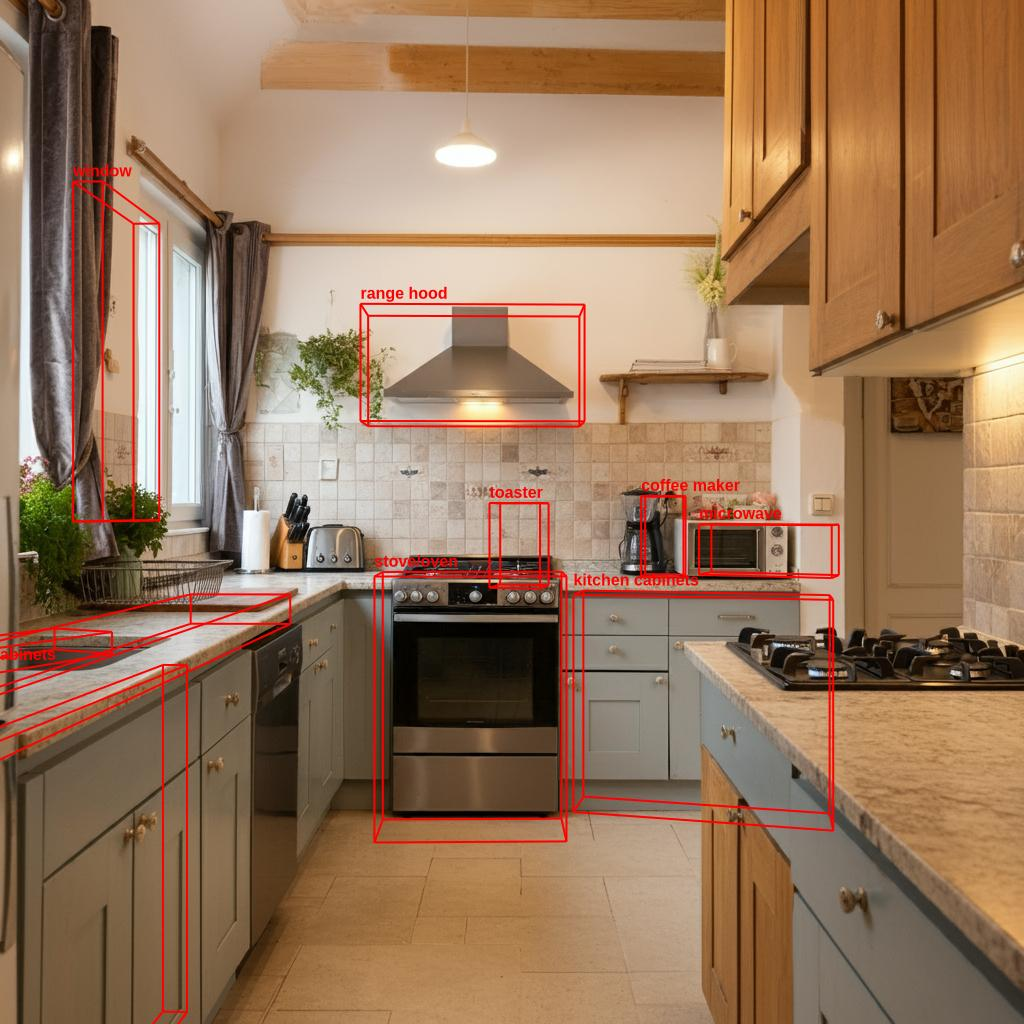

In [ ]:
const kitchen_bounding_box_image_code = parseCodeBlock(kitchen_bounding_box_image_response.text ?? "");
if (kitchen_bounding_box_image_code) {
  const kitchen_bounding_boxes: BoundingBox[] = JSON.parse(kitchen_bounding_box_image_code) as BoundingBox[];
  const kitchen_bounding_box_image_path = path.join("../assets", "Spatial_understanding_3d", "kitchen.jpg");
  const kitchen_bounding_box_image_with_boxes = await drawBoundingBoxes(
    kitchen_bounding_box_image_path,
    kitchen_bounding_boxes,
    "red",
    "16"
  );

  tslab.display.jpeg(new Uint8Array(kitchen_bounding_box_image_with_boxes));
}


## Search within the image

Like when using [Search within image](../quickstarts/Spatial_understanding.ipynb#scrollTo=wjP8ktS62QRv) in 2D, you can also ask Gemini to find specific objects in your images. It helps it to focus on what you are interested in instead of everything it sees (because it sees a lot!).


In [ ]:
const search_kitchen_response = await ai.models.generateContent({
  model: MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "kitchen.jpg")).toString("base64"),
      "image/jpeg"
    ),
    `
      Detect the 3D bounding boxes of range hood, stove top, oven, counter top, plants, shelf, cabinets
      Output a json list where each entry contains the object name in "label" and its 3D bounding box in "box_3d"
      The 3D bounding box format should be [x_center, y_center, z_center, x_size, y_size, z_size, roll, pitch, yaw].
    `,
  ],
  config: {
    temperature: 0.5,
  },
});
tslab.display.markdown(search_kitchen_response.text ?? "");


```json
[
  {"label": "range hood", "box_3d": [0.01,3.85,0.72,0.73,0.5,0.52,0,0,1]},
  {"label": "stove top", "box_3d": [-0.15,3.7,-0.36,0.73,0.49,0.25,0,0,1]},
  {"label": "oven", "box_3d": [-0.16,3.76,-0.71,0.74,0.56,0.93,0,0,1]},
  {"label": "counter top", "box_3d": [-1.17,2.48,-0.32,0.66,2.37,0.06,0,0,4]},
  {"label": "plants", "box_3d": [-1.4,2.67,-0.05,0.31,0.6,0.5,0,0,4]},
  {"label": "shelf", "box_3d": [1.05,4.11,0.59,0.68,0.21,0.11,0,0,-1]},
  {"label": "cabinets", "box_3d": [1.01,2.95,1.19,0.3,1.54,0.91,0,0,0]}
]
```

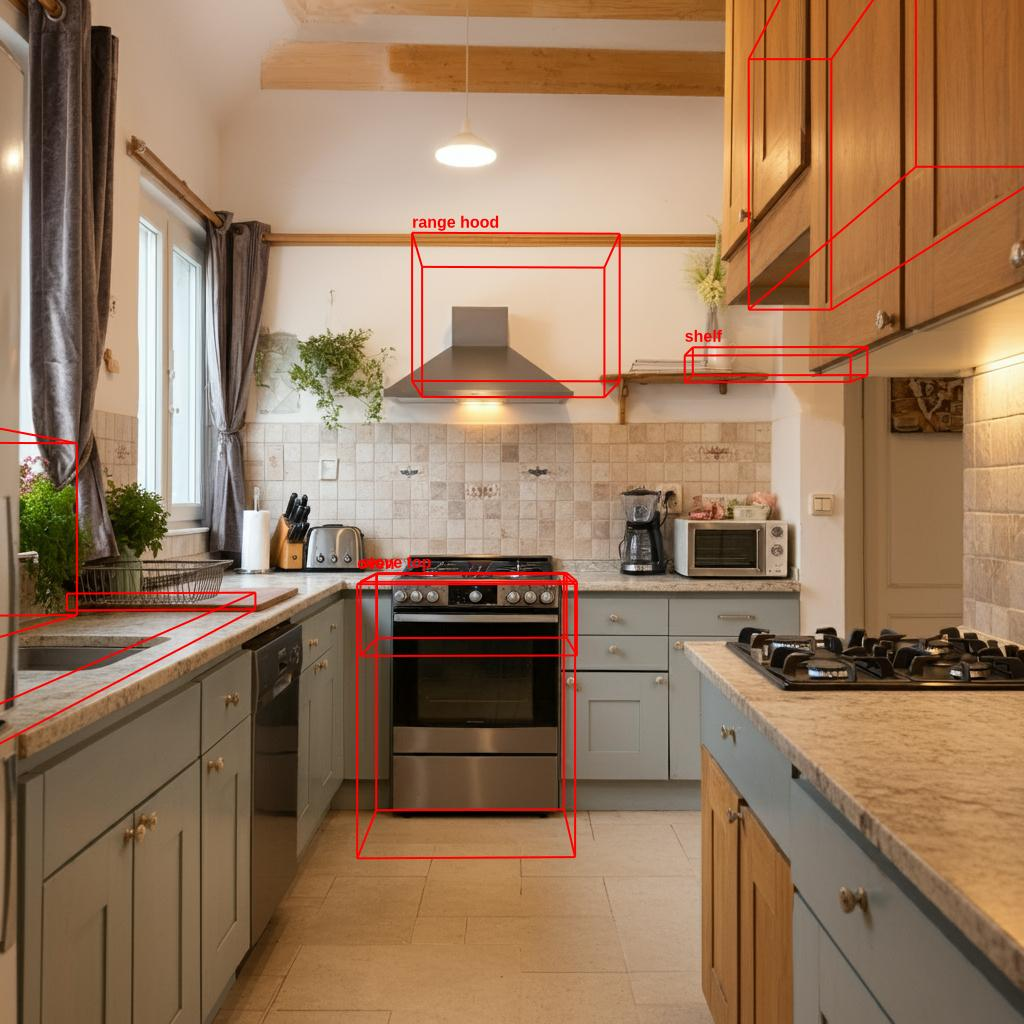

In [ ]:
const search_kitchen_code = parseCodeBlock(search_kitchen_response.text ?? "");
if (search_kitchen_code) {
  const search_kitchen_boxes: BoundingBox[] = JSON.parse(search_kitchen_code) as BoundingBox[];
  const search_kitchen_image_path = path.join("../assets", "Spatial_understanding_3d", "kitchen.jpg");
  const search_kitchen_image_with_boxes = await drawBoundingBoxes(
    search_kitchen_image_path,
    search_kitchen_boxes,
    "red",
    "16"
  );

  tslab.display.jpeg(new Uint8Array(search_kitchen_image_with_boxes));
}


## Other examples

Expend the next sub-section to see more examples of images and prompts you can use. Experiment with them and find what works bets for your use-case.


### Find appliances instead of furniture


In [ ]:
const find_kitchen_response = await ai.models.generateContent({
  model: MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "kitchen.jpg")).toString("base64"),
      "image/jpeg"
    ),
    `
      Detect the 3D bounding boxes of microwave, blender, toaster, 2 curtains, sink.
      Output a json list where each entry contains the object name in "label" and its 3D bounding box in "box_3d"
      The 3D bounding box format should be [x_center, y_center, z_center, x_size, y_size, z_size, roll, pitch, yaw].
    `,
  ],
  config: {
    temperature: 0.5,
  },
});
tslab.display.markdown(find_kitchen_response.text ?? "");


```json
[
  {"label": "microwave", "box_3d": [1.22,4.32,-0.21,0.45,0.34,0.26,1,0,-1]},
  {"label": "blender", "box_3d": [0.76,4.32,-0.12,0.23,0.21,0.43,1,0,-2]},
  {"label": "toaster", "box_3d": [-1.15,4.34,-0.18,0.23,0.32,0.21,1,0,0]},
  {"label": "2 curtains", "box_3d": [-1.48,3.68,0.66,0.32,1.74,1.79,1,0,1]},
  {"label": "sink", "box_3d": [-1.11,2.0,-0.35,0.4,0.53,0.16,1,0,1]}
]
```

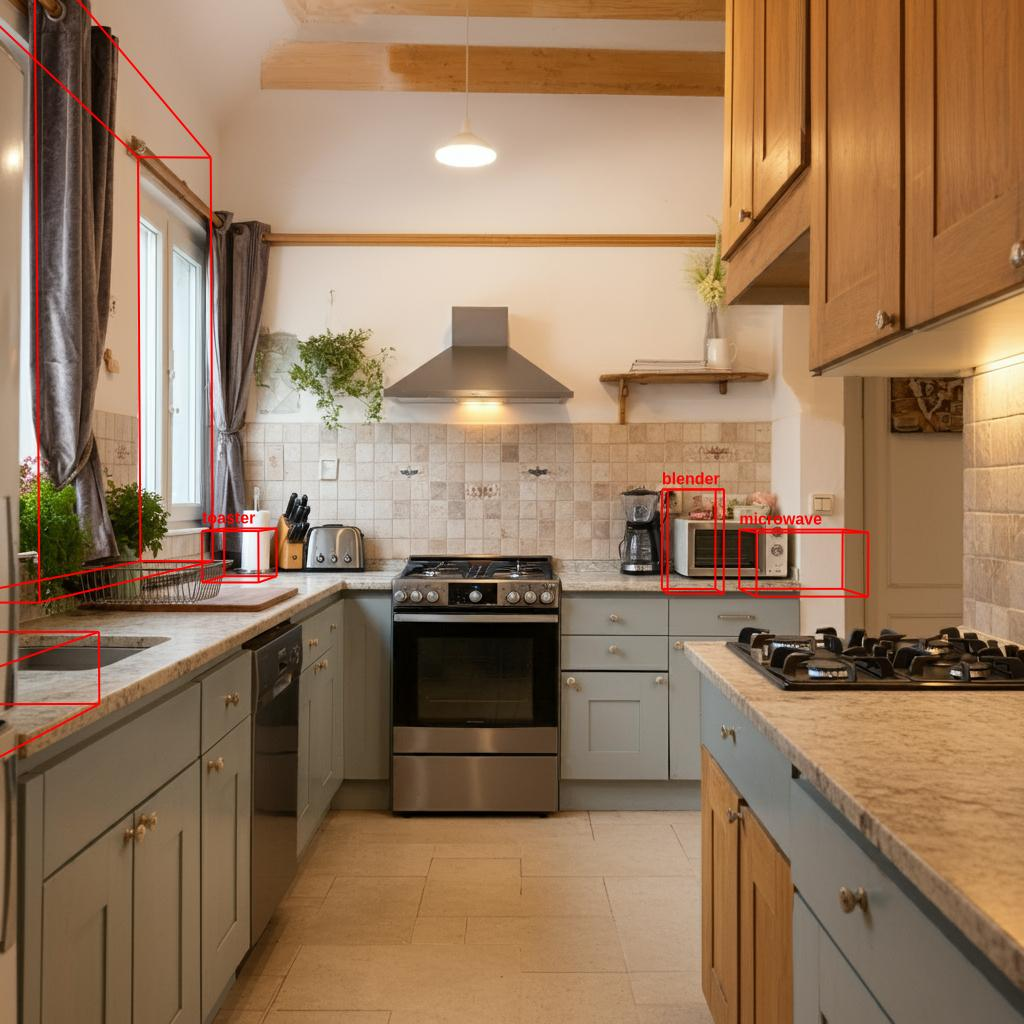

In [ ]:
const find_kitchen_response_code = parseCodeBlock(find_kitchen_response.text ?? "");
if (find_kitchen_response_code) {
  const find_kitchen_boxes: BoundingBox[] = JSON.parse(find_kitchen_response_code) as BoundingBox[];
  const find_kitchen_image_path = path.join("../assets", "Spatial_understanding_3d", "kitchen.jpg");
  const find_kitchen_image_with_boxes = await drawBoundingBoxes(
    find_kitchen_image_path,
    find_kitchen_boxes,
    "red",
    "16"
  );

  tslab.display.jpeg(new Uint8Array(find_kitchen_image_with_boxes));
}


### Kitchen mishap: spilled liquid on marble countertop


In [ ]:
const spill_image_response = await ai.models.generateContent({
  model: MODEL_ID,
  contents: [
    google.createPartFromBase64(
      fs.readFileSync(path.join("../assets", "Spatial_understanding_3d", "spill.jpg")).toString("base64"),
      "image/jpeg"
    ),
    'Find the 3D bounding boxes of no more than 10 items, include spill, return a json array with the objects having keys "label" and "box_3d"',
  ],
  config: {
    temperature: 0.5,
  },
});
tslab.display.markdown(spill_image_response.text ?? "");


```json
[
  {"label": "sugar container", "box_3d": [0.21,0.94,0.38,0.4,0.14,0.32,45,-1,-2]},
  {"label": "sugar bowl", "box_3d": [-0.09,0.83,0.13,0.18,0.24,0.18,-63,37,-53]},
  {"label": "spill", "box_3d": [0.28,0.81,-0.03,0.07,0.31,0.29,163,44,86]},
  {"label": "dish towel", "box_3d": [-0.29,0.73,-0.15,0.04,0.35,0.33,149,44,86]}
]
```

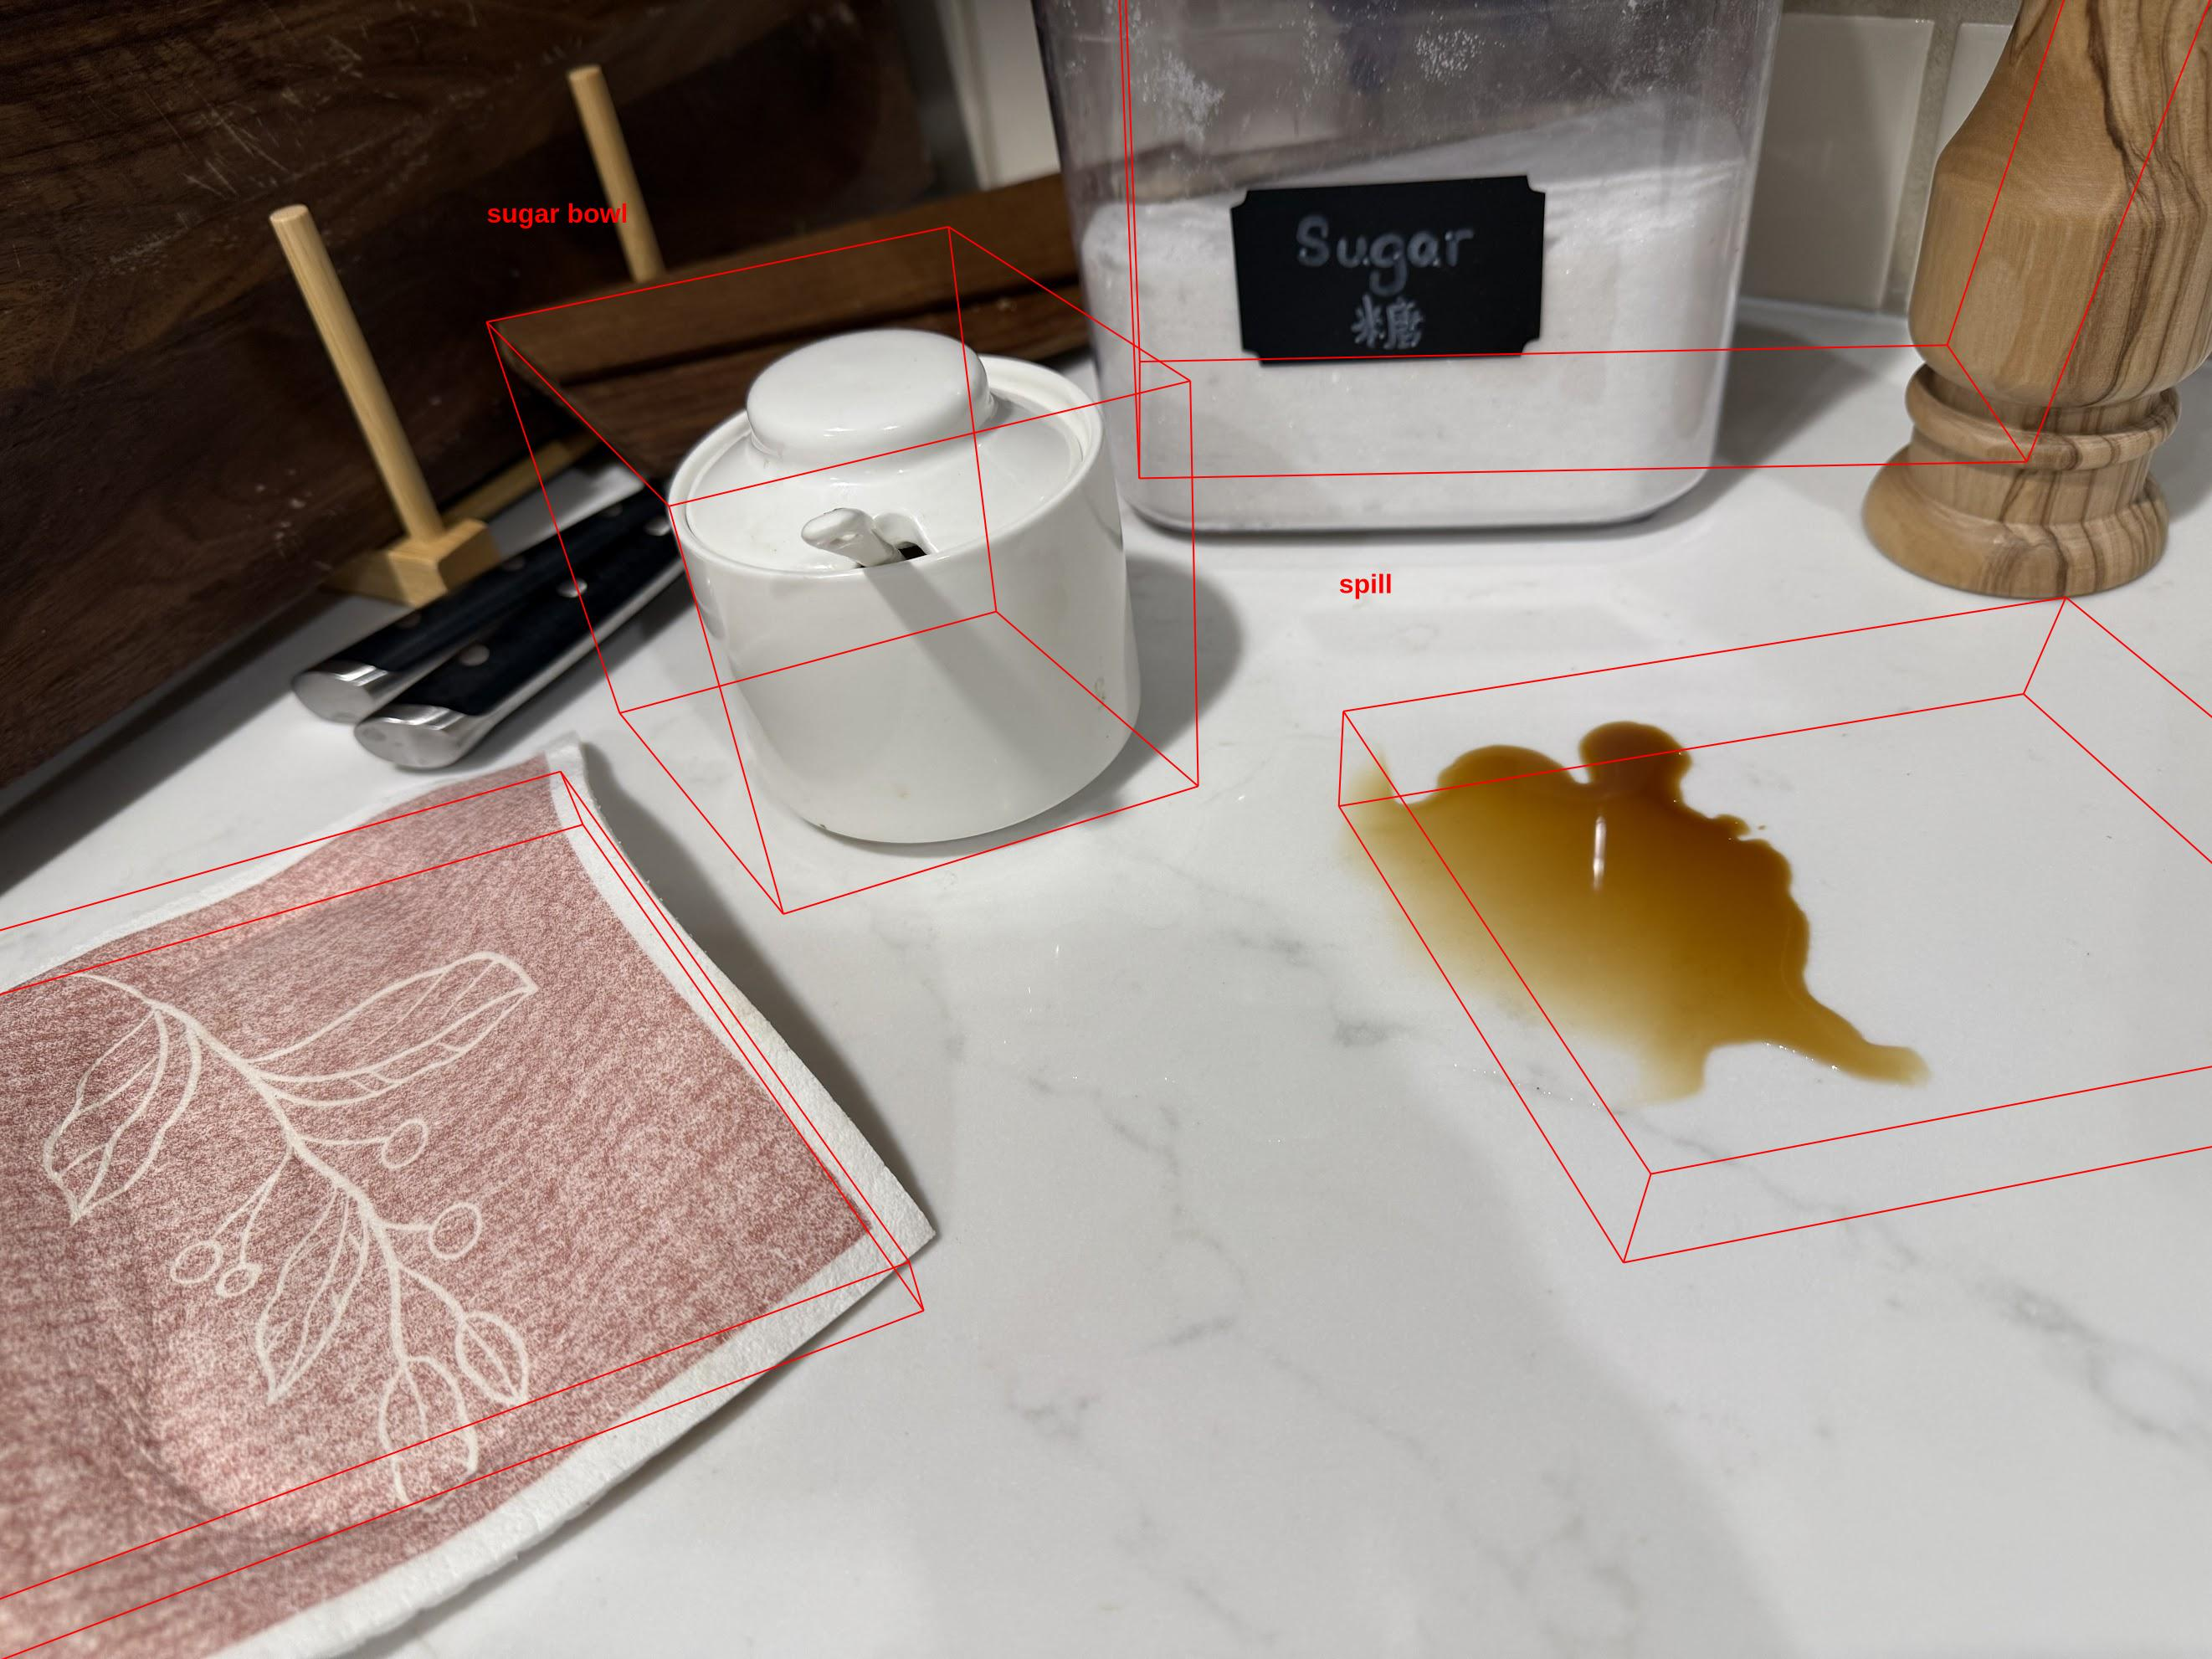

In [ ]:
const spill_image_response_code = parseCodeBlock(spill_image_response.text ?? "");
if (spill_image_response_code) {
  const spill_image_boxes: BoundingBox[] = JSON.parse(spill_image_response_code) as BoundingBox[];
  const spill_image_path = path.join("../assets", "Spatial_understanding_3d", "spill.jpg");
  const spill_image_with_boxes = await drawBoundingBoxes(spill_image_path, spill_image_boxes, "red", "32");

  tslab.display.jpeg(new Uint8Array(spill_image_with_boxes));
}


## What's next?

For a more end-to-end example, the code from the [Spatial understanding example](https://aistudio.google.com/starter-apps/spatial) from [Google AI Studio](https://aistudio.google.com/) is available on [GitHub](https://github.com/google-gemini/starter-applets/tree/main/spatial).

Related to image recognition and reasoning, other than the [2D spatial understanding](../quickstarts/Spatial_understanding.ipynb) notebook, [Market a jet backpack](Market_a_Jet_Backpack.ipynb) and [Guess the shape](Guess_the_shape.ipynb) examples are worth checking to continue exploring the capabilities of Gemini.

Other Gemini examples are available in the Gemini cookbook. The [video understanding](../quickstarts/Video_understanding.ipynb), [audio streaming](../quickstarts/Get_started_LiveAPI.ipynb) and [multiple tools](LiveAPI_plotting_and_mapping.ipynb) examples are in particular worth checking if you are interested in advanced capabilities of the model.
